# Gravitational Sonar
### Abstract: We present an algorithm -- which, if successful -- would be capable of predicting an approximate spacetime metric for a binary black hole system to within $<1\%$ error of the innermost-stable circular orbit (ISCO). Our algorithm, coined Gravitational Sonar, is valid in the Extreme-Mass Ratio Inspiral (EMRI) limit wherein $m_1>>m_2$. We will validate our algorithm for the Schwarzschild, Kerr, and Johannsen Metrics. We will demonstrate that the algorithm can be employed on LISA waveforms with noise $\sigma>0.05$ to test the No-Hair Theorem and probe for beyond-GR corrections.

# Library Installations

In [1]:
pip install pytearcat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.1/915.1 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.5 MB/s eta 0:00:00


In [2]:
pip install torch

In [3]:
pip install torchdiffeq

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import math
from torchdiffeq import odeint

In [5]:
import pytearcat as pt

In [6]:
!wget -q https://raw.githubusercontent.com/EliKiani/Optimizing_the_Optimizer_PINNs/main/_optimize.py

In [7]:
!sed -i 's/^from \.\([a-zA-Z_]*\) import/from scipy.optimize.\1 import/' _optimize.py

In [8]:
pip install torch torchdiffeq

In [9]:
pip install xitorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.9/117.9 kB 2.2 MB/s eta 0:00:00


In [10]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
from scipy.optimize import minimize as minimize_ssbroyden

In [11]:
!grep -n "^def _minimize_bfgs" _optimize.py

1415:def _minimize_bfgs(fun, x0, args=(), jac=None, callback=None,


In [12]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs

from scipy.optimize import minimize  # vanilla dispatcher — now calls the patched BFGS internals

# Import Gravitational Waveforms

We import gravitational waves which were created using a Numerical Kludge orbit-to-waveform mapping forward algorithm (i.e., Quadrupole Approximation + Kerr Geodesics). For a test case, we import just one gravitational wave (technically, there are two polarizations $h_+$ and $h_\times$, so there's two).

Things to test:
- Upgrade from 1 to 3 sets of waveforms, generated by observing the same geodesic from three perspectives (testing the idea of "GPS for Black Holes")
- Since $h_\times \to 0$ as $\theta \to \pi/2$, it may be interesting to try weighting edge-on observers differently than face-on observers to see if it increases the "signal" for numerically smaller components of the Kerr metric
- Not all metric components are created equal: They may not contribute equally to the waveform, so it's important to know which ones contribute the most or least. (Perhaps this would be a so-called "Fisher Analysis" to identify potential sloppy valleys)

θ_obs: 0
|h1|_min: tensor(0.0399)
|h1|_max: tensor(0.3530)


Text(0.5, 1.0, 'Gravitational Wave')

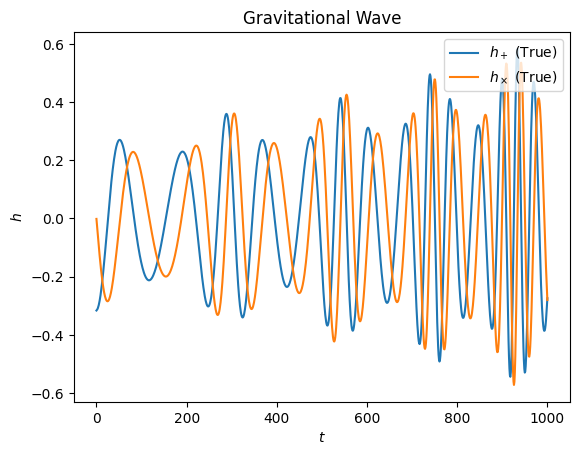

In [13]:
t_true, h_plus_true_obs1 = np.loadtxt('/content/waveform_real_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1000_observertheta_0.txt', unpack = True)
t_true, h_cross_true_obs1 = np.loadtxt('/content/waveform_imag_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1000_observertheta_0.txt', unpack = True)

h_plus_true_obs1 = torch.tensor(h_plus_true_obs1, dtype = torch.float32)
h_cross_true_obs1 = torch.tensor(h_cross_true_obs1, dtype = torch.float32)

print("θ_obs: 0")
print("|h1|_min:", min(h_plus_true_obs1**2 + h_cross_true_obs1**2))
print("|h1|_max:", max(h_plus_true_obs1**2 + h_cross_true_obs1**2))

plt.plot(t_true, h_plus_true_obs1, label = r"$h_+$ (True)")
plt.plot(t_true, h_cross_true_obs1, label = r"$h_\times$ (True)")

plt.legend(loc = "upper right")
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.title('Gravitational Wave')

# Input Parameters

The neural network is supplied with the exact orbital parameters (and thus, supplied with the correct initial conditions).

Things to test:
- Approach 1: A curriculum-based approach where one chops up the waveform into many pieces and iteratively trains on larger sections of the waveform (i.e., increase `t_test` from `[:600]` to `[:1200]` to `[:2000]`)
- Approach 2: Train on the entire waveform from the start, but iteratively sample the waveform with more points (i.e., increase `t_test` from `[::40]` to `[::100]` to `[::500]`)

In [14]:
rp_true = 10
ra_true = 14
a_true = 0.9
θmin_true = math.pi/4
θ_observed = [0]

In [15]:
t = torch.linspace(0, 1000, 1000)
t_final = 1000
t_test = t[:t_final]

print(len(t))
print(len(t_test))

1000
1000


In [16]:
h_plus_true = [h_plus_true_obs1[:t_final]]
h_cross_true = [h_cross_true_obs1[:t_final]]

# Neural Network

Build the neural network to be extremely small and simple (for starters).

Things to test:
- Increase neural network dimensions (although historically, this should be a last resort)
- Try different network architechtures (i.e., hourglass)
- Try different activation functions (i.e., ReLU, SiLU, etc.)
- Try different neural network inputs (i.e., [log(r), Θ] instead of [r, Θ])

In [17]:
import torch

class NN_Metric(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = torch.nn.Linear(2, 5) # 2 inputs -> 5 hidden features
    self.act = torch.nn.SiLU()       # non-linear hidden transform
    self.fc2 = torch.nn.Linear(5, 9) # 5 hidden features -> 9 outputs
    self.gtt_scalar = torch.nn.Parameter(torch.tensor(1.0))

  def forward(self, x):
    hidden = self.act(self.fc1(x))
    fields = self.fc2(hidden)
    return fields, self.gtt_scalar

In [18]:
def nn_input(r, θ):
  return torch.stack([
      1/r,
      torch.cos(θ).square()
  ])

In [19]:
torch.manual_seed(0)
net = NN_Metric()
x = torch.tensor([2.0, 1.57])
out = net(x)
print(out)

(tensor([ 0.0374,  0.2359, -0.2954,  0.0561,  0.1450, -0.0957, -0.2108,  0.0153,
         0.2342], grad_fn=<ViewBackward0>), Parameter containing:
tensor(1., requires_grad=True))


In [20]:
def Kerr(x, a, M=1):
  zero = torch.tensor(0.)
  r = x[1]
  θ = x[2]
  Δ = r**2 - 2*M*r + a**2
  Σ = r**2 + a**2 * (torch.cos(θ))**2
  A = (r**2 + a**2)**2 - Δ * a**2 * (torch.sin(θ))**2
  g_tt = -(1-2*M*r/Σ)
  g_rr = Σ/Δ
  g_θθ = Σ
  g_ϕϕ = A/Σ * (torch.sin(θ))**2
  g_tϕ = (-2*M*r/Σ) * a * (torch.sin(θ))**2
  row1 = torch.stack([g_tt, zero, zero, g_tϕ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tϕ, zero, zero, g_ϕϕ])
  kerr = torch.stack([row1, row2, row3, row4])
  return kerr

def g_Kerr(r, θ, M=1.0, a=a_true):

  Σ = lambda r, θ: r**2 + (a**2)*(torch.cos(θ))**2
  Δ = lambda r, θ: r**2 - 2*M*r + a**2
  A = (r**2 + a**2)**2 - Δ(r, θ) * a**2 * (torch.sin(θ))**2

  g_tt = - (1 - 2*M*r / Σ(r, θ))
  g_rr = Σ(r, θ) / Δ(r, θ)
  g_θθ = Σ(r, θ)
  g_φφ = A / Σ(r, θ) * (torch.sin(θ))**2
  g_tφ = - (2*M*r / Σ(r, θ)) * a * (torch.sin(θ))**2

  zero = torch.tensor(0.)
  row1 = torch.stack([g_tt, zero, zero, g_tφ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tφ, zero, zero, g_φφ])
  return torch.stack([row1, row2, row3, row4])

# Ansatz

This ansatz was designed very carefully with a two-scale approach in mind:
- The ansatz must approach the correct far-field Minkowski flat spacetime limit as $r\to ∞$
- The ansatz should respect any poles or be able to represent any divergences or blow-ups in metric components as $r\to r_+$ (Outer Event Horizon of Kerr). Examples: $g_{tt}=0$ is the Ergosphere, $g^{rr}=0$ is the Event Horizon, $g_{\theta\theta}=0$ is the Singularity, and $-g_{t\phi}/g_{\phi\phi}=\omega$
- As $r\to r_+$ during the inspiral, frame-dragging should cause the second, smaller black hole to orbit the central black hole at $\Omega \to \Omega_H$, the horizon's own angular spin rate. This should be reflected in the gravitational wave frequency, which is twice that of the orbital frequency. Thus, the gravitational wave frequency at the peak amplitude should directly tell us the size of the event horizon for the massive, central black hole. I believe that this deduction holds only for EMRIs (Extreme-Mass Ratio Inspirals), where the smaller, secondary black hole can be treated as a particle on a geodesic around the larger black hole.
- The ansatz is inspired by a post-newtonian expansion, with the 0th-order $O(g^0)$ term being flat, Minkowski spacetime; the 1st-order term $O(g^1)$ is Schwarzschild spacetime; the 2nd-order term $O(g^2)$ is Kerr spacetime; the 3rd-order term $O(g^3)$ or beyond would be corrections to Kerr or beyond-GR, ideally, although the ansatz does not have this yet perhaps.
- Try using `ln(r)` as an input for the neural network?

In [21]:
import torch.nn.functional as F

def NN_Ansatz(r, θ, NN, gtt_raw):
  A_tt = F.softplus(gtt_raw)

  g_tt = (-1
          + ((1/r) * A_tt)
          - (1/r**3) * (F.softplus(NN[0]) * (torch.cos(θ))**2))
  g_rr = ((1 + NN[1]/r) / (1 + NN[2]/r)
        + (1/r**2) * F.softplus(NN[3]) * ((F.softplus(NN[4])) - (torch.sin(θ))**2))
  g_θθ = r**2 + (torch.cos(θ))**2 * F.softplus(NN[5])
  g_φφ = torch.sin(θ)**2 * (r**2 + F.softplus(NN[6]))
  g_tφ = torch.sin(θ)**2 * (- 1/r * F.softplus(NN[7])
                          + 1/r**3 * F.softplus(NN[8]))

  zero = torch.tensor(0.)
  row1 = torch.stack([g_tt, zero, zero, g_tφ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tφ, zero, zero, g_φφ])
  return torch.stack([row1, row2, row3, row4])

In [22]:
def metric_from_network(network, r, θ, params_dict=None):
  inputs = nn_input(r, θ)

  if params_dict is None:
    fields, gtt_raw = network(inputs)
  else:
    fields, gtt_raw = torch.func.functional_call(
        network, params_dict, (inputs,)
    )

  return NN_Ansatz(r, θ, fields, gtt_raw)

## Gate: Check Ansatz can represent Kerr

In [23]:
import copy

M = 1.0
a = a_true
a2 = a**2
r_plus = M + math.sqrt(M**2 - a2)

def inverse_softplus(y):
    y = torch.as_tensor(y, dtype=torch.float32)
    return torch.log(torch.expm1(y))

def target_gphi_extra(r, θ):
    return a2 + 2*M*a2*torch.sin(θ).square() / r

def target_gtphi_extra(θ):
    return 2*M*a**3*torch.cos(θ).square()

def make_gate_model(NN2, NN3, NN5_target):
    gate_model = copy.deepcopy(net)
    with torch.no_grad():
        for p in gate_model.parameters():
            p.zero_()

        gate_model.gtt_scalar.copy_(inverse_softplus(2*M))

        bias = torch.zeros(9)
        bias[0] = inverse_softplus(2*M*a2)
        bias[1] = NN2
        bias[2] = NN3
        bias[3] = inverse_softplus(2*a2)
        bias[4] = inverse_softplus(NN5_target)
        bias[5] = inverse_softplus(a2)
        bias[6] = inverse_softplus(a2)
        bias[7] = inverse_softplus(2*M*a)
        bias[8] = 0.0  # overridden at each grid point
        gate_model.fc2.bias.copy_(bias)
    return gate_model

gate_original  = make_gate_model(NN2=2.0, NN3=0.0, NN5_target=4.9)
gate_corrected = make_gate_model(
    NN2=2*M-r_plus,
    NN3=-r_plus,
    NN5_target=(4*M**2 - 2*M*r_plus)/a2
)

In [24]:
r_values = torch.cat([torch.linspace(1.5, 3, 50), torch.linspace(3, 12, 20)])
θ_values = torch.linspace(math.pi/20, math.pi/2, 5)

def run_gate(gate_model):
    results = []
    with torch.no_grad():
        for r in r_values:
            for θ in θ_values:
                fields, gtt_raw = gate_model(nn_input(r, θ))
                fields = fields.clone()
                fields[6] = inverse_softplus(target_gphi_extra(r, θ))
                fields[8] = inverse_softplus(target_gtphi_extra(θ))

                pred = NN_Ansatz(r, θ, fields, gtt_raw)
                true = g_Kerr(r, θ)

                for name, idx in [
                    ("g_tt", (0,0)), ("g_rr", (1,1)),
                    ("g_θθ", (2,2)), ("g_φφ", (3,3)),
                    ("g_tφ", (0,3))
                ]:
                    results.append((name, pred[idx].item(), true[idx].item()))
    return results

for label, gm in [("ORIGINAL", gate_original), ("CORRECTED", gate_corrected)]:
    print(f"\\n--- {label} ---")
    results = run_gate(gm)
    for name in ["g_tt", "g_rr", "g_θθ", "g_φφ", "g_tφ"]:
        errs = [abs(100*(p-t)/t) for (n,p,t) in results if n == name]
        print(f"{name}: max % err = {max(errs):.4f}, mean % err = {sum(errs)/len(errs):.4f}")


\n--- ORIGINAL ---
g_tt: max % err = 4391.4076, mean % err = 30.8779
g_rr: max % err = 88.4670, mean % err = 19.1714
g_θθ: max % err = 0.0000, mean % err = 0.0000
g_φφ: max % err = 2.2853, mean % err = 0.2146
g_tφ: max % err = 12.3334, mean % err = 0.9568
\n--- CORRECTED ---
g_tt: max % err = 4391.4076, mean % err = 30.8779
g_rr: max % err = 34.5139, mean % err = 5.7723
g_θθ: max % err = 0.0000, mean % err = 0.0000
g_φφ: max % err = 2.2853, mean % err = 0.2146
g_tφ: max % err = 12.3334, mean % err = 0.9568


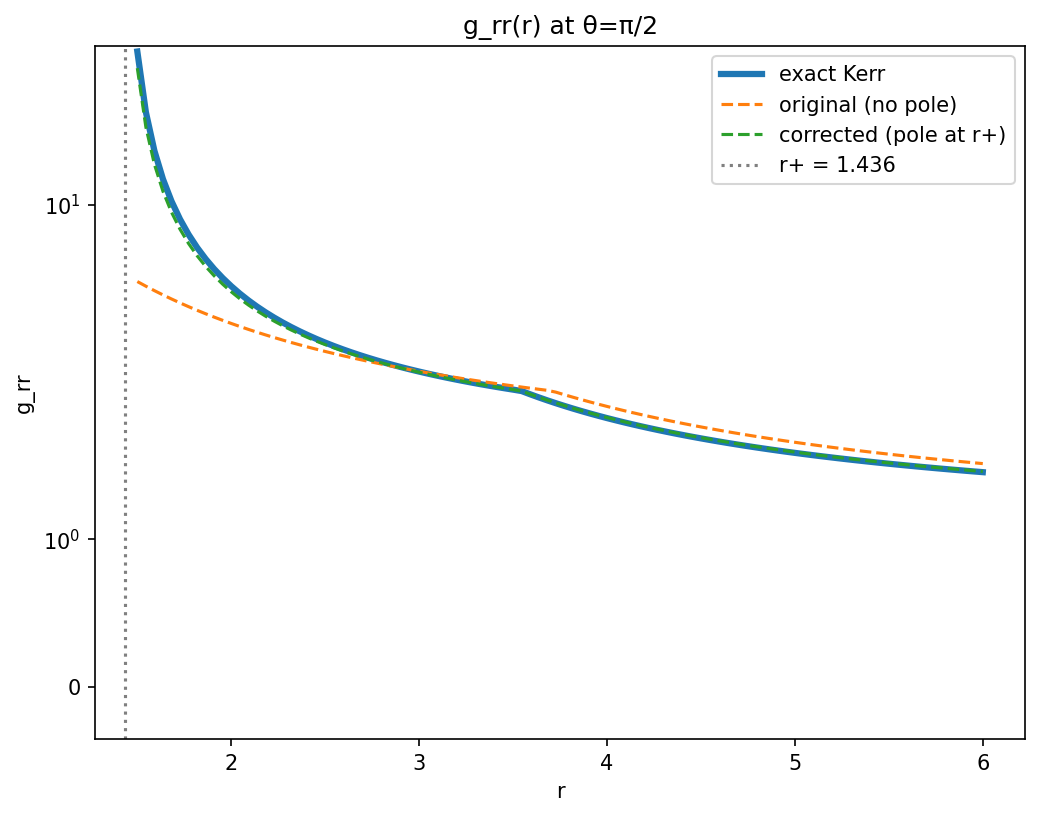

In [25]:
θ_fixed = torch.tensor(math.pi/2)
r_plot = torch.linspace(1.5, 6, 100)
grr_true, grr_orig, grr_corr = [], [], []

with torch.no_grad():
    for r in r_plot:
        grr_true.append(g_Kerr(r, θ_fixed)[1,1].item())
        for gm, store in [(gate_original, grr_orig), (gate_corrected, grr_corr)]:
            fields, gtt_raw = gm(nn_input(r, θ_fixed))
            fields = fields.clone()
            fields[6] = inverse_softplus(target_gphi_extra(r, θ_fixed))
            fields[8] = inverse_softplus(target_gtphi_extra(θ_fixed))
            store.append(NN_Ansatz(r, θ_fixed, fields, gtt_raw)[1,1].item())

plt.figure(figsize=(8,6), dpi=150)
plt.plot(r_plot, grr_true, label="exact Kerr", linewidth=3)
plt.plot(r_plot, grr_orig, label="original (no pole)", linestyle='dashed')
plt.plot(r_plot, grr_corr, label="corrected (pole at r+)", linestyle='dashed')
plt.axvline(r_plus, color='gray', linestyle=':', label=f"r+ = {r_plus:.3f}")
plt.yscale('symlog')
plt.xlabel("r")
plt.ylabel("g_rr")
plt.legend()
plt.title("g_rr(r) at θ=π/2")
plt.show()

In [26]:
torch.manual_seed(0)
net = NN_Metric()
print("# ---------- Network ---------- #\n", net)

r, θ = torch.tensor(2.0), torch.tensor(1.57)
print("# ---------- Test Input Tensor ---------- #\n", r, θ)
print(nn_input(r, θ))

NN_out, gtt_raw = net(nn_input(r, θ))
print("\n# ---------- Test Output Tensor ---------- #\n", NN_out)
print("\n# ---------- Raw g_tt Scalar ---------- #\n", gtt_raw)

g = NN_Ansatz(r, θ, NN_out, gtt_raw)
print(f"\n# ---------- Predicted Metric at (r={r}, θ={θ}) ---------- #\n",g)

g.sum().backward()
print(net.fc1.weight.grad)
net.zero_grad()

# ---------- Network ---------- #
 NN_Metric(
  (fc1): Linear(in_features=2, out_features=5, bias=True)
  (act): SiLU()
  (fc2): Linear(in_features=5, out_features=9, bias=True)
)
# ---------- Test Input Tensor ---------- #
 tensor(2.) tensor(1.5700)
tensor([5.0000e-01, 6.3405e-07])

# ---------- Test Output Tensor ---------- #
 tensor([ 0.1855,  0.0730, -0.1679,  0.2387,  0.1685,  0.0812, -0.0356, -0.0953,
         0.4631], grad_fn=<ViewBackward0>)

# ---------- Raw g_tt Scalar ---------- #
 Parameter containing:
tensor(1., requires_grad=True)

# ---------- Predicted Metric at (r=2.0, θ=1.5700000524520874) ---------- #
 tensor([[-0.3434,  0.0000,  0.0000, -0.2044],
        [ 0.0000,  1.0866,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  4.0000,  0.0000],
        [-0.2044,  0.0000,  0.0000,  4.6755]], grad_fn=<StackBackward0>)
tensor([[-5.3318e-02, -6.7612e-08],
        [-2.1651e-02, -2.7456e-08],
        [ 1.6740e-02,  2.1228e-08],
        [ 2.8628e-02,  3.6303e-08],
        [-2.0810

In [27]:
x = torch.tensor([0, 7.0, 1.5, 0])

def g(x):
  return metric_from_network(net, x[1], x[2])

g(x)

tensor([[-0.8124,  0.0000,  0.0000, -0.0917],
        [ 0.0000,  1.0321,  0.0000,  0.0000],
        [ 0.0000,  0.0000, 49.0036,  0.0000],
        [-0.0917,  0.0000,  0.0000, 49.4381]], grad_fn=<StackBackward0>)

# Hamiltonian

The Hamiltonian is constructed from a given metric as $H=\frac{1}{2}*p_\mu*g^{\mu\nu}*p_\nu$. I have now included a very simple dissipation term.

Things to test:
- For the initial test, dissipation will be baked in! The neural network will not be asked to predict it. Its only job will be to predict the kerr metric by making the right predictions for its 10 outputs.
- If the first preliminary test succeeds, where the network is able to predict the kerr metric (with dissipation baked in), then I will upgrade the dissipation term to be more realistic, reflecting post-newtonian $\dot \phi \propto r^{-7/2}$ dissipation
- If that test also succeeds, then I'll create a separate neural network `NN_Dissipative` which attempts to predict the dissipation whilst `NN_Conservative` predicts the entire kerr metric

In [28]:
def H_function(state, network, params_dict):
  x = state

  def H(state):
    t, r, θ, φ, p_t, p_r, p_θ, p_φ = state
    g = metric_from_network(network, r, θ, params_dict)
    inv_g = torch.linalg.inv(g)

    p = torch.stack([p_t, p_r, p_θ, p_φ])
    H = 0.5 * p @ inv_g @ p
    return H

  grad_H = torch.func.grad(H)(x)

  I4 = torch.eye(4)
  Z4 = torch.zeros(4,4)
  J = torch.cat([
      torch.cat([Z4, I4], 1),
      torch.cat([-I4, Z4], 1)
  ])

  Conservative = J @ grad_H
  Dissipative = (-10e-4) * torch.tensor([0, 0, 0, 0, 0, 0, 0, 1])

  du_dτ = Conservative + Dissipative

  dH_dpₜ = grad_H[4]
  dτ_dt = (dH_dpₜ)**(-1)

  du = du_dτ * dτ_dt
  du[0] = 1

  return du


# Quadrupole Approximation

In [29]:
def d2_dt2(v, dt):
    # uses second-order one-sided difference stencils at the endpoints; see https://doi.org/10.1090/S0025-5718-1988-0935077-0
    a = 2*v[0] - 5*v[1] + 4*v[2] - v[3]
    b = v[:-2] - 2*v[1:-1] + v[2:]
    c = 2*v[-1] - 5*v[-2] + 4*v[-3] - v[-4]

    return torch.cat([a.reshape(1), b, c.reshape(1)])/(dt**2)

def Soln2Orbit(soln, t, a):
  r = soln[:, 1]
  θ = soln[:, 2]
  ϕ = soln[:, 3]

  x, y, z = BoyerLindquist2Cartesian(r, θ, ϕ, a = a)
  orbit = torch.stack([x, y, z])

  return orbit

def BoyerLindquist2Cartesian(r, θ, ϕ, a):

  x = r * torch.sin(θ) * torch.cos(ϕ)
  y = r * torch.sin(θ) * torch.sin(ϕ)
  z = r * torch.cos(θ)

  return x, y, z

def Q_ij(orbit, t, μ = 1.0):
  N = orbit.shape[1]
  Q = torch.zeros(3, 3, N)

  for i in range(3):
    for j in range(3):
      for k in range(N):
        δij = 1.0 if i==j else 0.0
        x = orbit[:, k]
        r2 = torch.sum(x**2)
        Q[i, j, k] = μ * (x[i] * x[j] - (1/3) * δij * r2)
  return Q

def Q_ddot(Q, dt):
  Qdd = torch.zeros_like(Q)

  for i in range(3):
    for j in range(3):
      Qdd[i, j, :] = d2_dt2(Q[i, j, :], dt)

  return Qdd

In [30]:
def assert_uniform_time(t, rtol = 1e-3):
  dt = t[1] - t[0]
  assert torch.all(torch.abs(torch.diff(t) - dt) < rtol * torch.abs(dt)), "t must be uniformly sampled in coordinate time!"
  return dt

def Observer_Basis(θ_obs, ϕ_obs):
  n = [
      torch.sin(θ_obs) * torch.cos(ϕ_obs),
      torch.sin(θ_obs) * torch.sin(ϕ_obs),
      torch.cos(θ_obs)
  ]

  p = [
      torch.cos(θ_obs) * torch.cos(ϕ_obs),
      torch.cos(θ_obs) * torch.sin(ϕ_obs),
    - torch.sin(θ_obs)
  ]

  q = [
    - torch.sin(ϕ_obs),
      torch.cos(ϕ_obs),
      0.0
  ]

  return n, p, q

Observer_Basis(torch.tensor(0.0), torch.tensor(0.0))

def h(Qdd, θ_obs = 0.0, ϕ_obs = 0.0, D = 1.0):
  n, p, q = Observer_Basis(torch.tensor(θ_obs), torch.tensor(ϕ_obs))
  N = Qdd.shape[2]

  h_plus = torch.zeros(N)
  h_cross = torch.zeros(N)

  for k in range(N):
    h_plus_k = 0
    h_cross_k = 0
    for i in range(3):
      for j in range(3):

        e_plus = p[i] * p[j] - q[i] * q[j]
        e_cross = p[i] * q[j] + q[i] * p[j]

        h_plus_k += (1/D) * e_plus * Qdd[i, j, k]
        h_cross_k += (1/D) * e_cross * Qdd[i, j, k]

    h_plus[k] = h_plus_k
    h_cross[k] = h_cross_k

  return h_plus, h_cross

In [31]:
def create_gravityWave(t, soln, a, μ = 1.0, θ_obs = 0.0, ϕ_obs = 0.0, D = 1.0):
  orbit = Soln2Orbit(soln, t, a = a)
  dt = assert_uniform_time(t)
  Q = Q_ij(orbit, t, μ = μ)
  Qdd = Q_ddot(Q, dt)
  h_plus, h_cross = h(Qdd, θ_obs = θ_obs, ϕ_obs = ϕ_obs, D = D)

  return h_plus, h_cross

# Initial Conditions

In [32]:
from scipy import optimize

a_true = 0.9

def solve_ELQ(rₚ, rₐ, θmin, M = 1.0, a = a_true, μ = 1.0):
    Δₚ = rₚ**2 - 2*M*rₚ + a**2
    Δₐ = rₐ**2 - 2*M*rₐ + a**2

    def equations(x):
        E, Lz = x[0], x[1]
        Q_from_rₚ = (((rₚ**2 + a**2) * E - a * Lz)**2 - Δₚ * ((Lz-a*E)**2 + μ**2 * rₚ**2) ) / Δₚ

        F0 = ((rₐ**2 + a**2) * E - a * Lz)**2 - Δₐ * ( (Lz - a*E)**2 + μ**2 * rₐ**2 + Q_from_rₚ )
        F1 = Q_from_rₚ - math.cos(θmin)**2 * (a**2 * (μ**2 - E**2) + Lz**2 / math.sin(θmin)**2 )
        return [F0, F1]

    # Initial Guesses
    E0 = math.sqrt( 1 - 2 * M / (rₚ + rₐ) )
    L0 = math.sqrt( M * (rₚ + rₐ) / 2 )
    sol = optimize.fsolve(equations, [E0, L0])

    E, Lz = sol
    Δₚ_val = rₚ**2 - 2*M*rₚ + a**2
    Q = ( ((rₚ**2 + a**2) * E - a * Lz)**2 - Δₚ_val *  ( (Lz - a*E)**2 + μ**2 * rₚ**2 ) ) / Δₚ_val

    return E, Lz, Q

def make_u0(rₚ, rₐ, θmin, M = 1.0, a = a_true, μ = 1.0):
    E, Lz, Q = solve_ELQ(rₚ, rₐ, θmin, M = M, a = a, μ = μ)
    return torch.tensor([0.0, rₚ, θmin, 0.0,
            -E, 0.0, 0.0, Lz], dtype = torch.float32)

# RK4 Integration

In [33]:
def RK4(f, t, y, h):
  k1 = f(t, y)
  k2 = f(t + h/2, y + h/2 * k1)
  k3 = f(t + h/2, y + h/2 * k2)
  k4 = f(t + h, y + h * k3)
  y_next = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
  return y_next

def integrate(f, y0, t_array):
  h = t_array[1]-t_array[0]
  states = [y0]

  for i in range(len(t_array)-1):
    next_state = RK4(f, t_array[i], states[i], h)
    states.append(next_state)

  return torch.stack(states)

# Waveform Loss Term

In [34]:
def waveform_loss(network, eps = 1e-12):
  params_dict = dict(network.named_parameters())
  dyn = lambda t, state: H_function(state, network, params_dict)

  h_plus_pred = []
  h_cross_pred = []

  u0 = make_u0(rp_true, ra_true, θmin_true)
  predicted_geodesic = integrate(dyn, u0, t_test)

  waveformLoss = torch.zeros((), dtype=t_test.dtype, device=t_test.device)
  num_waveforms = 1

  for i in range(num_waveforms):
    pred_h_plus, pred_h_cross = create_gravityWave(t_test, predicted_geodesic, a_true, θ_obs = θ_observed[i], ϕ_obs = 0.0)
    h_plus_pred.append(pred_h_plus)
    h_cross_pred.append(pred_h_cross)

    squared_error = ( (h_plus_pred[i]-h_plus_true[i]).square()
                  + (h_cross_pred[i]-h_cross_true[i]).square() ).mean()

    truth_power = (
        h_plus_true[i].square() + h_cross_true[i].square()
    ).mean().detach()

    waveformLoss += squared_error / (truth_power + eps)

  waveformLoss /= num_waveforms
  return waveformLoss, h_plus_pred, h_cross_pred

## Waveform Gate: Reproducing the Kerr $h(t)$

In [35]:
def H_Kerr(state):
  def H(state):
    q = state[:4]
    p = state[4:]
    g = Kerr(q, a = a_true)
    inv_g = torch.linalg.inv(g)

    H = 0.5 * p @ inv_g @ p
    return H

  grad_H = torch.func.grad(H)(state)

  I4 = torch.eye(4)
  Z4 = torch.zeros(4,4)
  J = torch.cat([
      torch.cat([Z4, I4], 1),
      torch.cat([-I4, Z4], 1)
  ])

  Conservative = J @ grad_H
  Dissipative = (-10e-4) * torch.tensor([0, 0, 0, 0, 0, 0, 0, 1])

  du_dτ = Conservative + Dissipative

  dH_dpₜ = grad_H[4]
  dτ_dt = (dH_dpₜ)**(-1)

  du = du_dτ * dτ_dt
  du[0] = 1

  return du


In [36]:
u0_gate = make_u0(
    rp_true, ra_true, θmin_true,
    a=a_true
)

dyn_gate = lambda time, state: H_Kerr(state)

trajectory_gate = integrate(
    dyn_gate, u0_gate, t_test
)

h_plus_gate, h_cross_gate = create_gravityWave(
    t_test,
    trajectory_gate,
    a_true,
    θ_obs = θ_observed[0],
    ϕ_obs = 0.0
)

h_plus_reference = h_plus_true[0]
h_cross_reference = h_cross_true[0]

In [37]:
h_gate = torch.complex(h_plus_gate, h_cross_gate)
h_reference = torch.complex(h_plus_reference, h_cross_reference)

relative_L2 = (
    100 * torch.linalg.vector_norm(h_gate - h_reference)
    / (torch.linalg.vector_norm(h_reference) + 1e-12)
)

print("L2 Error:", relative_L2.item())

L2 Error: 0.024423493072390556


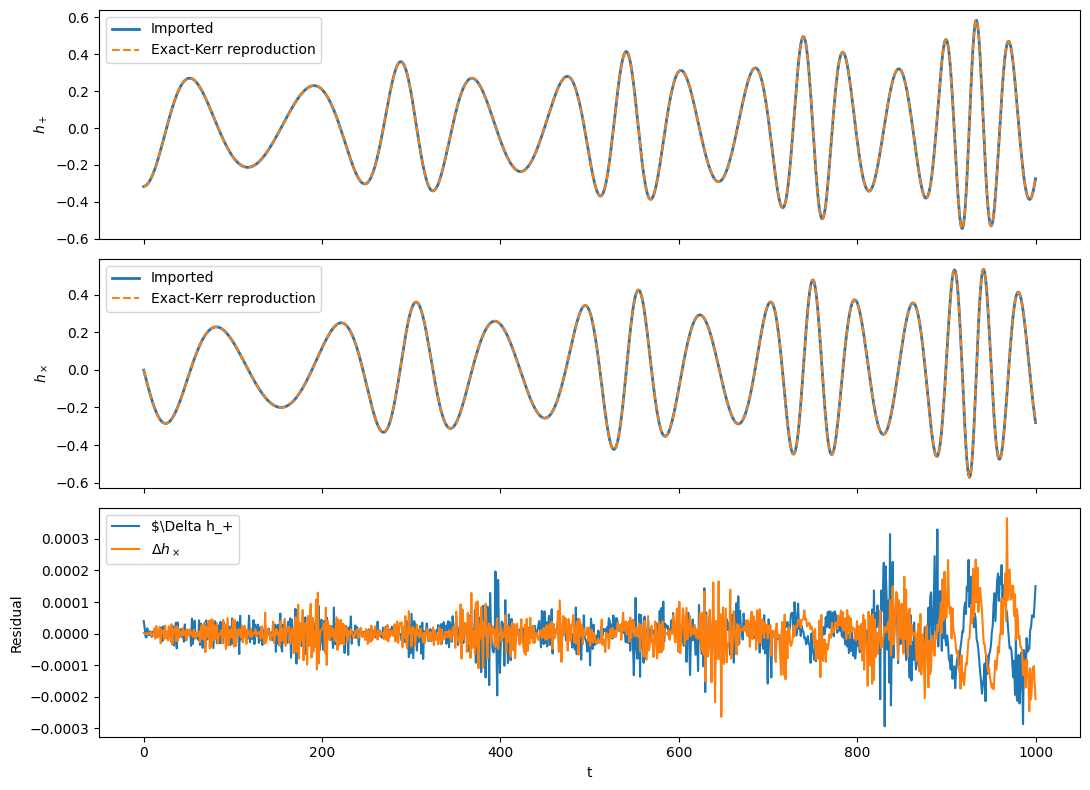

In [38]:
fig, ax = plt.subplots(3, 1, figsize = (11,8), sharex=True)

ax[0].plot(t_test, h_plus_reference, label = "Imported", linewidth=2)
ax[0].plot(t_test, h_plus_gate.detach(), "--", label = "Exact-Kerr reproduction")
ax[0].set_ylabel(r"$h_+$")
ax[0].legend()

ax[1].plot(t_test, h_cross_reference, label = "Imported", linewidth = 2)
ax[1].plot(t_test, h_cross_gate.detach(), "--", label = "Exact-Kerr reproduction")
ax[1].set_ylabel(r"$h_\times$")
ax[1].legend()

ax[2].plot(t_test, (h_plus_gate - h_plus_reference).detach(), label = r"$\Delta h_+")
ax[2].plot(t_test, (h_cross_gate-h_cross_reference).detach(), label = r"$\Delta h_\times$")
ax[2].set_xlabel("t")
ax[2].set_ylabel("Residual")
ax[2].legend()

plt.tight_layout()

# Ricci Loss Term

## Ricci Loss Term Components

In [39]:
def christ_awful(metric, x):
  partial_g = torch.func.jacfwd(metric)(x)
  ginv = torch.linalg.inv(metric(x))
  term1 = torch.einsum("ms, sab->mab", ginv, partial_g)
  term2 = torch.einsum("ms, sba->mab", ginv, partial_g)
  term3 = torch.einsum("ms, abs->mab", ginv, partial_g)
  christoffel = 0.5 * (term1 + term2 - term3)
  return christoffel

In [40]:
def Riemann(metric, x):
  dGamma = torch.func.jacfwd(christ_awful, argnums=1)(metric, x)
  term1 = torch.einsum("abvu->abuv", dGamma)
  term2 = torch.einsum("abuv->abuv", dGamma)
  term3 = torch.einsum("aup,pbv->abuv", christ_awful(metric, x), christ_awful(metric, x))
  term4 = torch.einsum("avp,pbu->abuv", christ_awful(metric, x), christ_awful(metric, x))
  Riemann = term1 - term2 + term3 - term4
  return Riemann

In [41]:
def Ricci(metric, x):
  ricci = torch.einsum("abav->bv", Riemann(metric, x))
  return ricci

## Gate: Test on Exact Schwarzschild & Kerr Metrics

In [42]:
def Schwarzschild(x, M=1):
  zero = torch.tensor(0.)
  r = x[1]
  θ = x[2]
  g_tt = -(1-2*M/r)
  g_rr = (1-2*M/r)**(-1)
  g_θθ = r**2
  g_ϕϕ = r**2 * (torch.sin(θ))**2
  row1 = torch.stack([g_tt, zero, zero, zero])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([zero, zero, zero, g_ϕϕ])
  schild = torch.stack([row1, row2, row3, row4])
  return schild

In [43]:
x = torch.tensor([0.0, 10.0, math.pi/2, 0.0])
input_spin = torch.tensor(0.9, dtype = x.dtype)
kerr_gate = lambda x: Kerr(x, a=input_spin)
schwarzschild_gate = lambda x: Schwarzschild(x)
print("Kerr Gate:", Ricci(kerr_gate, x))
print("\nSchwarzschild Gate:", Ricci(schwarzschild_gate, x))

Kerr Gate: tensor([[ 3.4925e-10,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  2.3283e-09, -3.3654e-16,  0.0000e+00],
        [ 0.0000e+00,  1.1484e-15,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.7881e-07]])

Schwarzschild Gate: tensor([[-1.1642e-10,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  2.3283e-09,  8.8818e-16,  0.0000e+00],
        [ 0.0000e+00,  8.8818e-16,  1.4901e-08,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.4901e-08]])


# Frequency Loss Term

## Why `torch.angle()` fails

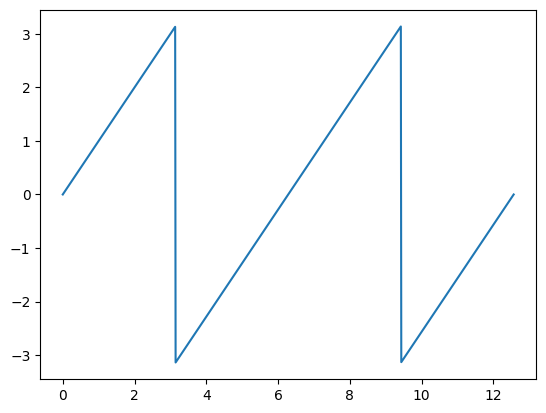

In [44]:
θ = torch.linspace(0, 4*math.pi, 1000)
wrapped = torch.atan2(torch.sin(θ), torch.cos(θ))

plt.plot(θ, wrapped)

## $\omega=|h_{true}| * Im\frac{\dot h}{h+\epsilon}$

In [45]:
def freq_loss(h_plus_pred, h_cross_pred, h_plus_true, h_cross_true, eps = 1e-12):
    h_pred = torch.complex(h_plus_pred, h_cross_pred)
    h_true = torch.complex(h_plus_true, h_cross_true)
    dt = assert_uniform_time(t_test)

    eps_power = 1e-4 * h_true.abs().square().mean().detach()

    def omega(h):
      z = h[:-1]
      dh = torch.diff(h) / dt
      return torch.imag(torch.conj(z) * dh) / (
          z.abs().square() + eps_power
      )

    omega_pred = omega(h_pred)
    omega_true = omega(h_true)
    weight = h_true[:-1].abs().square()

    raw = (weight * (omega_pred - omega_true).square()).mean()
    normalization = (weight * omega_true.square()).mean().detach()

    freqLoss = raw / (normalization + eps)
    return freqLoss, omega_true

## Gate: $L_{\omega}(h_{true},h_{true})=0$

In [46]:
freq_loss(h_plus_true_obs1, h_cross_true_obs1, h_plus_true_obs1, h_cross_true_obs1)

(tensor(0.),
 tensor([0.0585, 0.0591, 0.0591, 0.0592, 0.0593, 0.0594, 0.0596, 0.0597, 0.0599,
         0.0601, 0.0604, 0.0606, 0.0609, 0.0611, 0.0614, 0.0616, 0.0619, 0.0621,
         0.0623, 0.0625, 0.0627, 0.0628, 0.0629, 0.0630, 0.0630, 0.0630, 0.0629,
         0.0628, 0.0626, 0.0624, 0.0621, 0.0618, 0.0615, 0.0611, 0.0607, 0.0603,
         0.0598, 0.0593, 0.0588, 0.0583, 0.0578, 0.0572, 0.0567, 0.0562, 0.0557,
         0.0552, 0.0547, 0.0543, 0.0538, 0.0534, 0.0530, 0.0526, 0.0523, 0.0520,
         0.0517, 0.0514, 0.0511, 0.0509, 0.0507, 0.0505, 0.0504, 0.0503, 0.0502,
         0.0501, 0.0500, 0.0499, 0.0499, 0.0499, 0.0499, 0.0499, 0.0499, 0.0499,
         0.0499, 0.0499, 0.0499, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0499,
         0.0499, 0.0499, 0.0498, 0.0497, 0.0496, 0.0495, 0.0494, 0.0493, 0.0491,
         0.0489, 0.0487, 0.0485, 0.0483, 0.0481, 0.0478, 0.0476, 0.0473, 0.0470,
         0.0468, 0.0465, 0.0462, 0.0459, 0.0456, 0.0453, 0.0450, 0.0448, 0.0445,
         0.0442

## Gate: Kerr Circular, Equatorial Frequency $\Omega=\frac{M^{1/2}}{r^{3/2}+aM^{1/2}}$

Text(0.5, 1.0, 'Circular Kerr Orbit ($r=10$)')

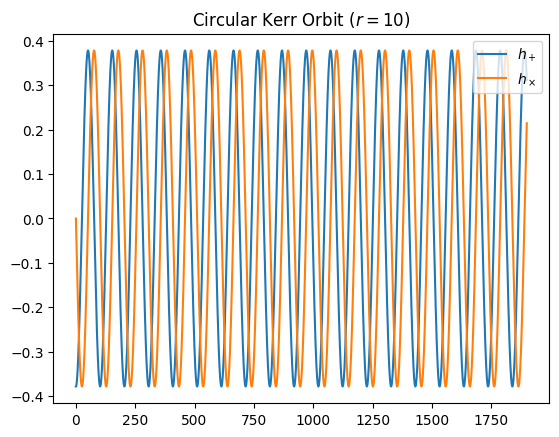

In [47]:
t_true, h_plus_true_circle = np.loadtxt('circular_orbit_kerr_r=10_h_real.txt', unpack = True)
t_true, h_cross_true_circle = np.loadtxt('circular_orbit_kerr_r=10_h_imag.txt', unpack = True)

h_plus_true_circle = torch.tensor(h_plus_true_circle, dtype = torch.float32)
h_cross_true_circle = torch.tensor(h_cross_true_circle, dtype = torch.float32)

plt.plot(t_true, h_plus_true_circle, label = r"$h_+$")
plt.plot(t_true, h_cross_true_circle, label = r"$h_\times$")
plt.legend(loc = "upper right")
plt.title(r"Circular Kerr Orbit ($r=10$)")

In [48]:
freq_loss(h_plus_true_obs1, h_cross_true_obs1, h_plus_true_circle[:t_final], h_cross_true_circle[:t_final])[1][:10]

tensor([0.0073, 0.0073, 0.0073, 0.0073, 0.0073, 0.0073, 0.0073, 0.0073, 0.0073,
        0.0073])

# Boundary Condition Loss Term

## 4 Tricks: Square, Normalize, Exponentiate, and Weight

In [49]:
import torch

def resid(metric, x):
    g_rr = metric(x)[1,1]
    g_rr_inv = 1/g_rr
    return g_rr_inv

def boundaryConditionLoss(metric):
  M = 1
  zero = torch.tensor(0.)
  r_vals = torch.linspace(1*M, 2.01*M, 10)
  θ_vals = torch.linspace(0, math.pi/2, 2)
  tau = 2e-3

  roots = []
  root_residuals = [] # g^{rr}(r_H, θ)^2 -- penalizes "no real zero here"
  sign_penalties = []


  for θ in θ_vals:
    badness_vals = []
    for r in r_vals:
      x = torch.stack([zero, r, θ, zero])
      badness = resid(metric, x)**2 # square it
      badness_vals.append(badness) # add it to the array

    weights = torch.softmax(-torch.stack(badness_vals)/tau, dim=0)
    weighted_average = (weights * r_vals).sum()
    roots.append(weighted_average)

    x_root = torch.stack([zero, weighted_average, θ, zero])
    root_residuals.append(resid(metric, x_root)**2)

    x_lo = torch.stack([zero, r_vals[0], θ, zero])
    x_hi = torch.stack([zero, r_vals[-1], θ, zero])
    sign_penalties.append(F.relu(resid(metric, x_lo) * resid(metric, x_hi))) # >0 only if same-sign (no crossing)

  location_consistency = torch.var(torch.stack(roots))
  zero_crossing_penalty = torch.stack(root_residuals).mean()
  sign_change_penalty = torch.stack(sign_penalties).mean()

  L2_norm_BC_loss = location_consistency + zero_crossing_penalty + sign_change_penalty

  return L2_norm_BC_loss, roots

## Gate: Kerr $a=0, r_H=1.43M$

In [50]:
metric_fn = lambda x: Kerr(x, a = 0.9)
boundaryConditionLoss(metric_fn)

(tensor(6.8913e-05), [tensor(1.4287), tensor(1.4401)])

## Gate: Schwarzschild $a=0, r_H=2M$

In [51]:
metric_fn = lambda x: Kerr(x, a = 0)
boundaryConditionLoss(metric_fn)

(tensor(3.4315e-05), [tensor(1.9884), tensor(1.9884)])

# Loss Function

Things to test:
- Exponential ricci grid sampling (i.e., `r_grid = 1 +. 10^([-3, 3, 10])`) so that near-Horizon is sampled more strongly than far-away
- A very good training log required to log / print out the weights of each loss term as they change, the predicted metric as it evolves during training, etc.

In [52]:
π = math.pi

P_WAVEFORM = 1.0
P_RICCI = 0.8
P_FREQUENCY = 0.1
P_BC = 0.1

def loss(network):
  # --------- RICCI LOSS ---------------
  r_grid = torch.linspace(2, 20, 10)
  θ_grid = torch.linspace(π/20, π/2, 2)

  def g(x):
    return metric_from_network(network, x[1], x[2])

  ricci_sum = torch.zeros(())
  ricci_count = 0

  for r in r_grid:
    for θ in θ_grid:
      zero = torch.tensor(0.)
      x = torch.stack([zero, r, θ, zero])
      ricci_sum += Ricci(g, x).pow(2).sum()
      ricci_count += 1

  ricciLoss = ricci_sum / ricci_count

  # --------- WAVEFORM LOSS ---------------
  waveformLoss, pred_h_real, pred_h_imag = waveform_loss(network)

  # --------- BOUNDARY LOSS ---------------
  boundaryCondition_Loss, roots = boundaryConditionLoss(g)

  # --------- FREQUENCY LOSS ---------------
  freq_Loss = freq_loss(
      pred_h_real[0], pred_h_imag[0],
      h_plus_true[0], h_cross_true[0])[0]

  # --------- TOTAL LOSS ---------------
  total_loss = (P_WAVEFORM * waveformLoss
              + P_RICCI * ricciLoss
              + P_FREQUENCY * freq_Loss
              + P_BC * boundaryCondition_Loss)

  return (total_loss, waveformLoss,
          ricciLoss.detach(), freq_Loss,
          boundaryCondition_Loss.detach(), roots)

# Checkpoints

In [53]:
import os

CHECKPOINT_PATH = "/content/sonar_v4_0.pt"

def save_checkpoint(stride_idx, epoch, n, loss_history):
  torch.save({
      "net_state": net.state_dict(),
      "stride_idx": stride_idx,
      "epoch": epoch,
      "n": n,
      "loss_history": loss_history,
  }, CHECKPOINT_PATH)

def load_checkpoint():
  if not os.path.exists(CHECKPOINT_PATH):
    return None
  return torch.load(CHECKPOINT_PATH)

# Diagnostics Log

In [54]:
from prettytable import PrettyTable
import time

def rel_L2_error(pred, true, eps = 1e-12):
  return 100 * torch.sqrt(
                          torch.sum((pred - true) ** 2) / (torch.sum((true) ** 2) + eps)
                         )

# -------- Psuedo-code structure --------
# for each radius:
  # evaluate predicted metric at each \theta on a grid [π/20, π/4, π/3, π/2]
  # stack the \theta-profile of the metrics into a tensor of shape [n_theta, 4, 4]
  # compute L2 error for each metric component (i.e., g_tt, g_rr, etc.) across all theta values via L2(g_pred[:, \mu, \nu], g_true[:, \mu, \nu])
  # add that relative angular-profile error at a given radius for a given metric component as a row to the diagnostics table

def log_diagnostics(
    network, total_loss,
    w, r, f, b, roots, n,
    elapsed_time
  ):

  r_grid = [2, 3, 4, 5, 6, 12, 20] # Use these explicit r values
  θ_grid = [π/20, π/4, π/3, π/2] # Use these explicit θ values

  gtt_error_vals = []
  grr_error_vals = []
  gθθ_error_vals = []
  gϕϕ_error_vals = []
  gtϕ_error_vals = []
  ricci_error_vals = []

  param = next(network.parameters())

  for r_val in r_grid:
    pred_vec = []
    true_vec = []
    ricci_at_radius = []

    for θ in θ_grid:
      r_t = torch.tensor(r_val, dtype = param.dtype, device = param.device)
      θ_t = torch.tensor(θ, dtype = param.dtype, device = param.device)

      pred_g = metric_from_network(network, r_t, θ_t)
      true_g = g_Kerr(r_t, θ_t)

      pred_vec.append(pred_g)
      true_vec.append(true_g)

    pred_vec = torch.stack(pred_vec)
    true_vec = torch.stack(true_vec)

    gtt_error_vals.append(rel_L2_error(pred_vec[:, 0, 0], true_vec[:, 0, 0]).detach().item())
    grr_error_vals.append(rel_L2_error(pred_vec[:, 1, 1], true_vec[:, 1, 1]).detach().item())
    gθθ_error_vals.append(rel_L2_error(pred_vec[:, 2, 2], true_vec[:, 2, 2]).detach().item())
    gϕϕ_error_vals.append(rel_L2_error(pred_vec[:, 3, 3], true_vec[:, 3, 3]).detach().item())
    gtϕ_error_vals.append(rel_L2_error(pred_vec[:, 0, 3], true_vec[:, 0, 3]).detach().item())

  metric_table = PrettyTable()
  metric_table.title = "Metric Relative L2 Error Across θ (%)"
  metric_table.field_names = [
      "Component",
      *[f"r={r_val}" for r_val in r_grid]
  ]

  metric_table.add_row(["g_tt", *gtt_error_vals])
  metric_table.add_row(["g_rr", *grr_error_vals])
  metric_table.add_row(["g_θθ", *gθθ_error_vals])
  metric_table.add_row(["g_ϕϕ", *gϕϕ_error_vals])
  metric_table.add_row(["g_tϕ", *gtϕ_error_vals])
  metric_table.float_format = ".2"

  total_value = total_loss.detach().item()
  w_relL2 = 100 * torch.sqrt(w.clamp_min(0)).item()
  A_tt = torch.nn.functional.softplus(network.gtt_scalar).detach().item()
  r_H = torch.stack(roots).mean().detach().item()

  w_Loss = P_WAVEFORM * w.item()
  r_LOSS = P_RICCI * r.item()
  f_LOSS = P_FREQUENCY * f.item()
  b_LOSS = P_BC * b.item()

  print(
      f"iter={n:4d} | "
      f"time={elapsed_time:7.1f}s | "
      f"total={total_value:.3e} | "
      f"W_err={w_relL2:5.1f}% | "
      f"A_tt={A_tt:.4f} | "
      f"r_H={r_H:.4f} | "
      f"contrib: W={w_Loss:.2e}, F={f_LOSS:.2e},"
      f"R={r_LOSS:.2e}, BC={b_LOSS:.2e}"
  )

  print(metric_table)

  return metric_table

# Training

In [55]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
import scipy.optimize._minimize as scipy_dispatch

scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
scipy_dispatch._minimize_bfgs = ssbroyden_patch._minimize_bfgs

from scipy.optimize import minimize as minimize_ssbroyden

In [56]:
def report_wave_freq_gradients(network, waveformLoss, freqLoss):
  params = list(network.parameters())

  grad_W = torch.autograd.grad(
      P_WAVEFORM * waveformLoss,
      params,
      retain_graph=True
  )

  grad_F = torch.autograd.grad(
      P_FREQUENCY * freqLoss,
      params,
      retain_graph=True
  )

  grad_W = torch.cat([g.flatten() for g in grad_W])
  grad_F = torch.cat([g.flatten() for g in grad_F])

  G_W = torch.linalg.vector_norm(grad_W)
  G_F = torch.linalg.vector_norm(grad_F)

  cosine = torch.dot(grad_W, grad_F) / (G_W * G_F + 1e-12)

  print(
      f"gradients: G_W={G_W.item():.3e} | "
      f"G_F={G_F.item():.3e} | "
      f"cos={cosine.item():+.3e} | "
  )

In [57]:
loss_history = []
waveform_loss_history = []
ricci_loss_history = []
frequency_loss_history = []
boundaryCondition_loss_history = []

n = 0
start_stage_idx = 0
start_epoch = 0

ckpt = load_checkpoint()

if ckpt is not None:
  net.load_state_dict(ckpt["net_state"])
  n = ckpt["n"]
  loss_history = ckpt["loss_history"]

  start_stage_idx = ckpt["stride_idx"]
  start_epoch = ckpt["epoch"] + 1
  print(f"Resumed from stride {start_stage_idx}, epoch {start_epoch}, n={n}")

t_full = t.detach().clone()
hp_full = h_plus_true_obs1
hc_full = h_cross_true_obs1

schedule = [
    (25, 45),
    (50, 40),
    (100, 35),
    (200, 30),
    (300, 25),
    (350, 30),
    (400, 20),
    (500, 20)
]

optimizer = torch.optim.Adam(net.parameters(), lr = 1e-2)
start_time = time.time()

for stage_idx, (window, epochs) in enumerate(schedule):
  if stage_idx < start_stage_idx:
    continue

  lr_stage = 1e-2 if window <= 300 else 2e-3 * (400/window)
  optimizer = torch.optim.Adam(net.parameters(), lr = lr_stage)

  t_test = t_full[:window]
  h_plus_true = [hp_full[:window]]
  h_cross_true = [hc_full[:window]]
  epoch0 = start_epoch if stage_idx == start_stage_idx else 0

  print(f"\\nAdam stage {stage_idx + 1}/{len(schedule)}: samples [0:{window}], {epochs} iterations")

  for epoch in range(epoch0, epochs):
    optimizer.zero_grad()

    total_loss, w, r, f, b, roots = loss(net)

    if (n + 1) % 10 == 0:
      report_wave_freq_gradients(net, w, f)

    elapsed_time = time.time() - start_time
    log_diagnostics(net, total_loss,
                    w, r, f, b, roots,
                    n, elapsed_time)

    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        net.parameters(),
        1.0,
        error_if_nonfinite=True
    )

    optimizer.step()

    loss_history.append(total_loss.item())
    waveform_loss_history.append(P_WAVEFORM*w.item())
    ricci_loss_history.append(P_RICCI*r.item())
    frequency_loss_history.append(P_FREQUENCY*f.item())
    boundaryCondition_loss_history.append(P_BC*b.item())

    n += 1

    if n % 10 == 0:
      save_checkpoint(stage_idx, epoch, n, loss_history)

  save_checkpoint(stage_idx, epochs - 1, n, loss_history)

  print(f"Adam complete: {n} total iterations")

\nAdam stage 1/8: samples [0:25], 45 iterations
iter=   0 | time=    2.9s | total=3.006e-01 | W_err= 27.7% | A_tt=1.3133 | r_H=1.0082 | contrib: W=7.67e-02, F=1.37e-02,R=1.01e-01, BC=1.09e-01
+--------------------------------------------------------------------+
|               Metric Relative L2 Error Across θ (%)                |
+-----------+--------+-------+-------+-------+-------+-------+-------+
| Component |  r=2   |  r=3  |  r=4  |  r=5  |  r=6  |  r=12 |  r=20 |
+-----------+--------+-------+-------+-------+-------+-------+-------+
|    g_tt   | 317.17 | 60.57 | 32.58 | 22.22 | 16.84 |  6.84 |  3.81 |
|    g_rr   | 77.32  | 53.90 | 41.07 | 33.11 | 27.71 | 13.96 |  8.39 |
|    g_θθ   |  1.46  |  0.69 |  0.40 |  0.26 |  0.18 |  0.05 |  0.02 |
|    g_ϕϕ   | 15.17  |  5.85 |  2.82 |  1.58 |  0.98 |  0.17 |  0.05 |
|    g_tϕ   | 76.42  | 69.00 | 66.39 | 65.16 | 64.48 | 63.23 | 62.92 |
+-----------+--------+-------+-------+-------+-------+-------+-------+
iter=   1 | time=    6.9s |

In [58]:
def as_float(x):
  return float(x.detach().cpu()) if torch.is_tensor(x) else float(x)

In [59]:
def loss_and_gradient(x):
  ref = next(net.parameters())
  x_t = torch.as_tensor(x, dtype=ref.dtype, device=ref.device)

  with torch.no_grad():
    torch.nn.utils.vector_to_parameters(x_t, net.parameters())

  net.zero_grad(set_to_none=True)

  try:
    L, w, r, f, b, roots = loss(net)

    if not torch.isfinite(L):
      raise FloatingPointError

    L.backward()
    grad = torch.nn.utils.parameters_to_vector(
        [p.grad for p in net.parameters()]
    )

    if not torch.isfinite(grad).all():
      raise FloatingPointError

    loss_history.append(L.item())
    waveform_loss_history.append(P_WAVEFORM*w.item())
    ricci_loss_history.append(P_RICCI*r.item())
    frequency_loss_history.append(P_FREQUENCY*f.item())
    boundaryCondition_loss_history.append(P_BC*b.item())

    return(
        float(L.detach().cpu()),
        grad.detach().cpu().numpy().astype(np.float64),
    )

  except(RuntimeError, FloatingPointError):
    # Reject singular/non-physical line-search trials
      return 1e30, np.zeros_like(x, dtype=np.float64)

def ssbroyden_callback(intermediate_result):
  with torch.no_grad():
    ref = next(net.parameters())
    accepted_x = torch.as_tensor(
        intermediate_result.x,
        dtype=ref.dtype,
        device=ref.device
    )
    torch.nn.utils.vector_to_parameters(
        accepted_x,
        net.parameters()
    )

  save_checkpoint(
        len(schedule) - 1,
        schedule[-1][1] - 1,
        n,
        loss_history
  )

  elapsed = time.time() - bfgs_start_time

  print(
      "BFGS Loss:", intermediate_result.fun,
      "evaluations:", getattr(intermediate_result, "nfev", "?"),
      "elapsed:", elapsed
  )

x0 = (
    torch.nn.utils.parameters_to_vector(net.parameters())
    .detach().cpu().numpy().astype(np.float64)
)

t_test = t_full
h_plus_true = [hp_full]
h_cross_true = [hc_full]

gate_loss, gate_grad = loss_and_gradient(x0)

print("Full-window starting loss", gate_loss)
print("Full-window gradient norm:", np.linalg.norm(gate_grad))
print("Finite gradient:", np.isfinite(gate_grad).all())

Full-window starting loss 1e+30
Full-window gradient norm: 0.0
Finite gradient: True


In [60]:
bfgs_start_time = time.time()

result = minimize_ssbroyden(
    loss_and_gradient,
    x0,
    jac=True,
    method="BFGS",
    callback=ssbroyden_callback,
    options={
        "maxiter": 60,
        "gtol": 1e-4,
        "method_bfgs": "SSBroyden2",
        "initial_scale": False,
        "disp": True,
    },
)

with torch.no_grad():
  ref = next(net.parameters())
  final_x = torch.as_tensor(result.x, dtype=ref.dtype, device=ref.device)
  torch.nn.utils.vector_to_parameters(final_x, net.parameters())

bfgs_elapsed = time.time() - bfgs_start_time
total_elapsed = time.time() - start_time

print("\nBFGS Summary")
print("success:", result.success)
print("status:", result.status)
print("message:", result.message)
print("iterations:", result.nit)
print("function evaluations", result.nfev)
print("gradient evaluations", result.njev)
print("final loss:", result.fun)
print("BFGS elapsed:", bfgs_elapsed / 60, "minutes")
print("total Adam+BFGS elapsed:", total_elapsed / 60, "minutes")

if hasattr(result, "jac"):
  print("final ||gradient||:", np.linalg.norm(result.jac, ord=np.inf))
if "precision loss" in str(result.message).lower():
  print(
      "Float32 precision floor possible. "
      "If loss decreased and gradients remained finite, retry with gtol=1e-3"
  )

Optimization terminated successfully.
         Current function value: 1000000000000000019884624838656.000000
         Iterations: 0
         Function evaluations: 1
         Gradient evaluations: 1

BFGS Summary
success: True
status: 0
message: Optimization terminated successfully.
iterations: 0
function evaluations 1
gradient evaluations 1
final loss: 1e+30
BFGS elapsed: 0.8945634643236796 minutes
total Adam+BFGS elapsed: 64.73573231299719 minutes
final ||gradient||: 0.0


# Results

In [61]:
with torch.no_grad():
  final_x = torch.as_tensor(result.x, dtype=ref.dtype, device=ref.device)
  torch.nn.utils.vector_to_parameters(final_x, net.parameters())

In [62]:
t_test = t_full
h_plus_true = [hp_full]
h_cross_true = [hc_full]

final_total, final_w, final_r, final_f, final_b, final_roots = loss(net)

log_diagnostics(
    net,
    final_total,
    final_w,
    final_r,
    final_f,
    final_b,
    final_roots,
    n + result.nit,
    time.time() - start_time
)

iter= 245 | time= 3910.2s | total=1.903e+26 | W_err=1379655063961600.0% | A_tt=1.9110 | r_H=1.7114 | contrib: W=1.90e+26, F=9.33e+20,R=2.49e-03, BC=1.37e-04
+-------------------------------------------------------------------+
|               Metric Relative L2 Error Across θ (%)               |
+-----------+-------+-------+-------+-------+-------+-------+-------+
| Component |  r=2  |  r=3  |  r=4  |  r=5  |  r=6  |  r=12 |  r=20 |
+-----------+-------+-------+-------+-------+-------+-------+-------+
|    g_tt   | 44.75 |  5.23 |  3.10 |  2.34 |  1.89 |  0.85 |  0.49 |
|    g_rr   | 59.10 |  7.85 |  3.59 |  2.31 |  1.72 |  0.73 |  0.43 |
|    g_θθ   |  2.67 |  1.21 |  0.68 |  0.44 |  0.30 |  0.07 |  0.03 |
|    g_ϕϕ   | 16.02 |  6.29 |  3.07 |  1.74 |  1.10 |  0.20 |  0.06 |
|    g_tϕ   | 43.89 | 44.77 | 45.35 | 45.73 | 46.00 | 46.72 | 47.03 |
+-----------+-------+-------+-------+-------+-------+-------+-------+


Component,r=2,r=3,r=4,r=5,r=6,r=12,r=20
g_tt,44.75,5.23,3.10,2.34,1.89,0.85,0.49
g_rr,59.10,7.85,3.59,2.31,1.72,0.73,0.43
g_θθ,2.67,1.21,0.68,0.44,0.30,0.07,0.03
g_ϕϕ,16.02,6.29,3.07,1.74,1.10,0.20,0.06
g_tϕ,43.89,44.77,45.35,45.73,46.00,46.72,47.03


In [63]:
x0 = torch.nn.utils.parameters_to_vector(net.parameters()).detach().clone()
print(x0)

tensor([ 1.7509, -0.7460,  0.6108, -0.8104, -0.6931, -0.3581,  0.4450, -0.3911,
         1.3699, -0.4194, -0.5005, -0.8386, -0.3732, -0.7222,  0.1102, -0.6084,
        -0.0412,  0.6132,  0.4612, -0.0694,  0.2103, -0.1900,  0.0314, -0.3116,
        -0.2375, -0.3348,  0.8235,  1.1564,  0.2533, -0.0801,  0.6009, -0.5239,
         0.2230, -0.5646, -0.4869, -0.4633, -0.1080,  0.0121,  0.7686, -0.1288,
         0.5201,  0.1368, -0.0351,  0.3248,  0.0566, -0.1281, -0.1374,  0.2456,
         0.4711,  0.1876, -0.1186, -0.4351,  0.0193, -0.3160, -0.8541, -0.1075,
         0.7882,  1.1010,  0.6270, -0.2560,  0.7596, -0.3285,  0.3888, -0.9400,
         0.3209, -0.0414, -0.1854, -0.0425,  0.4267, -0.7113])


In [64]:
print(dict(net.named_parameters()))

{'gtt_scalar': Parameter containing:
tensor(1.7509, requires_grad=True), 'fc1.weight': Parameter containing:
tensor([[-0.7460,  0.6108],
        [-0.8104, -0.6931],
        [-0.3581,  0.4450],
        [-0.3911,  1.3699],
        [-0.4194, -0.5005]], requires_grad=True), 'fc1.bias': Parameter containing:
tensor([-0.8386, -0.3732, -0.7222,  0.1102, -0.6084], requires_grad=True), 'fc2.weight': Parameter containing:
tensor([[-0.0412,  0.6132,  0.4612, -0.0694,  0.2103],
        [-0.1900,  0.0314, -0.3116, -0.2375, -0.3348],
        [ 0.8235,  1.1564,  0.2533, -0.0801,  0.6009],
        [-0.5239,  0.2230, -0.5646, -0.4869, -0.4633],
        [-0.1080,  0.0121,  0.7686, -0.1288,  0.5201],
        [ 0.1368, -0.0351,  0.3248,  0.0566, -0.1281],
        [-0.1374,  0.2456,  0.4711,  0.1876, -0.1186],
        [-0.4351,  0.0193, -0.3160, -0.8541, -0.1075],
        [ 0.7882,  1.1010,  0.6270, -0.2560,  0.7596]], requires_grad=True), 'fc2.bias': Parameter containing:
tensor([-0.3285,  0.3888, -0.9400

In [65]:
torch.nn.utils.vector_to_parameters(torch.tensor(x0, dtype=torch.float32), net.parameters())
params_dict = dict(net.named_parameters())
dyn = lambda t, state: H_function(state, net, params_dict)
u0 = make_u0(rp_true, ra_true, θmin_true)
traj = integrate(dyn, u0, t_test)
hp_trained, hc_trained = create_gravityWave(t_test, traj, a_true, θ_obs=0.0)

/tmp/ipykernel_10611/610292433.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.nn.utils.vector_to_parameters(torch.tensor(x0, dtype=torch.float32), net.parameters())


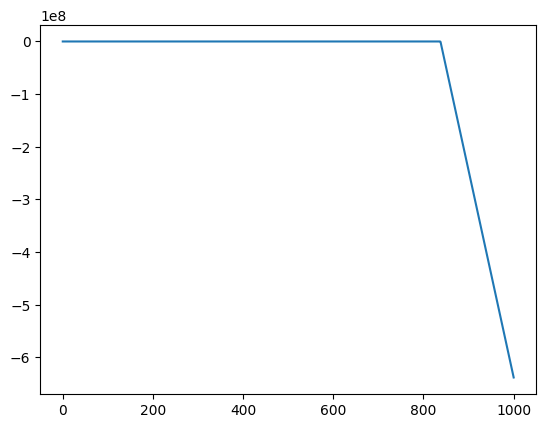

In [66]:
plt.plot(t_test, traj[:,1].detach().numpy())

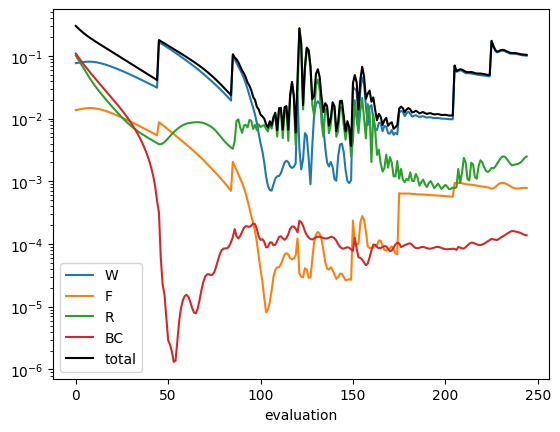

In [67]:
for h, label in [
    (waveform_loss_history, 'W'),
    (frequency_loss_history, 'F'),
    (ricci_loss_history, 'R'),
    (boundaryCondition_loss_history, 'BC')
]:
  plt.plot(h, label = label)

plt.plot(loss_history, 'k', label='total')
plt.yscale('log')
plt.xlabel('evaluation')
plt.legend()

Stride of 10 Elements Comparison:

Time: tensor([  0.0000,  10.0100,  20.0200,  30.0300,  40.0400,  50.0500,  60.0601,
         70.0701,  80.0801,  90.0901, 100.1001, 110.1101, 120.1201, 130.1301,
        140.1401, 150.1501, 160.1602, 170.1702, 180.1802, 190.1902, 200.2002,
        210.2102, 220.2202, 230.2302, 240.2402, 250.2502, 260.2603, 270.2703,
        280.2803, 290.2903, 300.3003, 310.3103, 320.3203, 330.3303, 340.3403,
        350.3503, 360.3604, 370.3704, 380.3804, 390.3904, 400.4004, 410.4104,
        420.4204, 430.4304, 440.4404, 450.4504, 460.4604, 470.4705, 480.4805,
        490.4905, 500.5005, 510.5105, 520.5205, 530.5305, 540.5405, 550.5505,
        560.5605, 570.5706, 580.5806, 590.5906, 600.6006, 610.6106, 620.6206,
        630.6306, 640.6406, 650.6506, 660.6606, 670.6707, 680.6807, 690.6907,
        700.7007, 710.7107, 720.7207, 730.7307, 740.7407, 750.7507, 760.7607,
        770.7708, 780.7808, 790.7908, 800.8008, 810.8108, 820.8208, 830.8308,
        840.8408, 850.8

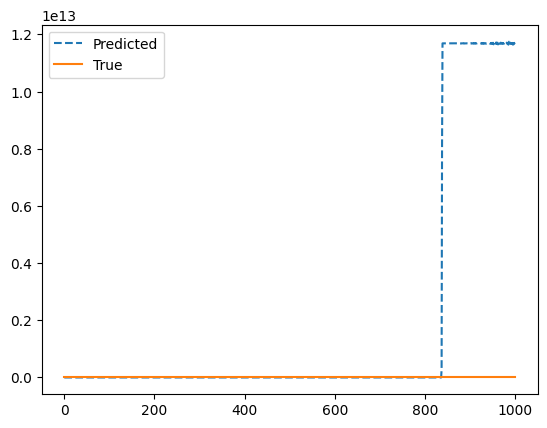

In [68]:
plt.plot(t_test.detach(), hp_trained.detach(), label = "Predicted", linestyle='dashed')
plt.plot(t_test.detach(), h_plus_true[0], label = "True", linestyle = "solid")

print("Stride of 10 Elements Comparison:\n")
print("Time:", t_test.detach()[::10])
print("hp_trained.detach:", hp_trained.detach()[::10])
print("h_plus_true:", h_plus_true[0][::10])

plt.legend()

In [69]:
from matplotlib.lines import Line2D

def compare_metrics(NN):
  M, a = 1.0, a_true
  r_plus = M + math.sqrt(M**2 - a**2)

  r_vals = np.linspace(2, ra_true, 20)
  θ_vals = [math.pi/2, math.pi/3, math.pi/4, math.pi/20]

  # fig, axes = plt.subplots(2, 3)

  figs = []
  colors = ['C0', 'C1', 'C2', 'C3']

  components = ["g_{tt}", "g_{rr}", "g_{θθ}", "g_{ϕϕ}", "g_{tϕ}"]
  component_index = [(0,0), (1,1), (2,2), (3,3), (0,3)]

  pred_by_component = []
  true_by_component = []

  for i in range(len(components)):
    fig, ax = plt.subplots(figsize=(8,6), dpi=150)
    true_metric, pred_metric = [], []
    for θ in θ_vals:
      for r in r_vals:
        r = torch.tensor(r, dtype = torch.float32)
        θ = torch.tensor(θ, dtype = torch.float32)

        true_g = g_Kerr(r, θ)[component_index[i]]
        pred_g = metric_from_network(NN, r, θ)[component_index[i]]

        pred_metric.append(pred_g)
        true_metric.append(true_g)

    pred_i = torch.stack(pred_metric).reshape(4,20).T
    true_i = torch.stack(true_metric).reshape(4,20).T
    pred_by_component.append(pred_i)
    true_by_component.append(true_i)

    for θ_idx in range(len(θ_vals)):
      ax.plot(r_vals, pred_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='dashed')
      ax.plot(r_vals, true_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='solid')

    handles = [Line2D([0], [0], color = colors[i], label=f"θ={round(θ_vals[i],2)}") for i in range(len(θ_vals))]
    handles += [
        Line2D([0], [0], color='k', linestyle='dashed', label='Predicted'),
        Line2D([0], [0], color='k', linestyle='solid', label='True')
    ]
    ax.legend(handles=handles)
    ax.set_title(f"${components[i]}$ Component")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(components[i])
    figs.append(fig)

  return figs, pred_by_component, true_by_component

def angular_comparison_metrics(NN):
  M, a = 1.0, a_true
  r_plus = M + math.sqrt(M**2 - a**2)

  r_vals = np.linspace(2, ra_true, 20)
  θ_vals = [math.pi/2, math.pi/3, math.pi/4, 0]

  figs = []
  colors = ['C0', 'C1', 'C2', 'C3']

  components = ["g_{tt}", "g_{rr}", "g_{θθ}", "g_{ϕϕ}", "g_{tϕ}"]
  component_index = [(0,0), (1,1), (2,2), (3,3), (0,3)]

  pred_diff_by_component = []
  true_diff_by_component = []

  for i in range(len(components)):
    fig, ax = plt.subplots(figsize=(8,6), dpi=150)
    true_metric, pred_metric = [], []
    for θ in θ_vals:
      for r in r_vals:
        r = torch.tensor(r, dtype = torch.float32)
        θ = torch.tensor(θ, dtype = torch.float32)

        true_g = g_Kerr(r, θ)[component_index[i]]
        pred_g = metric_from_network(NN, r, θ)[component_index[i]]

        pred_metric.append(pred_g)
        true_metric.append(true_g)

    pred_i = torch.stack(pred_metric).reshape(4,20).T
    true_i = torch.stack(true_metric).reshape(4,20).T

    pred_diff_i = pred_i - pred_i[:, 0:1]
    true_diff_i = true_i - true_i[:, 0:1]

    pred_diff_by_component.append(pred_diff_i)
    true_diff_by_component.append(true_diff_i)

    for θ_idx in range(len(θ_vals)):
      ax.plot(r_vals, pred_diff_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='dashed')
      ax.plot(r_vals, true_diff_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='solid')

    ax.set_title(f"${components[i]}$ Component Angular Difference")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(components[i])
    handles = [Line2D([0], [0], color = colors[i], label=f"θ={round(θ_vals[i],2)}") for i in range(len(θ_vals))]
    handles += [
        Line2D([0], [0], color='k', linestyle='dashed', label='Predicted'),
        Line2D([0], [0], color='k', linestyle='solid', label='True')
    ]
    ax.legend(handles=handles)
    figs.append(fig)

  return figs, pred_diff_by_component, true_diff_by_component

/tmp/ipykernel_10611/1297034714.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  θ = torch.tensor(θ, dtype = torch.float32)


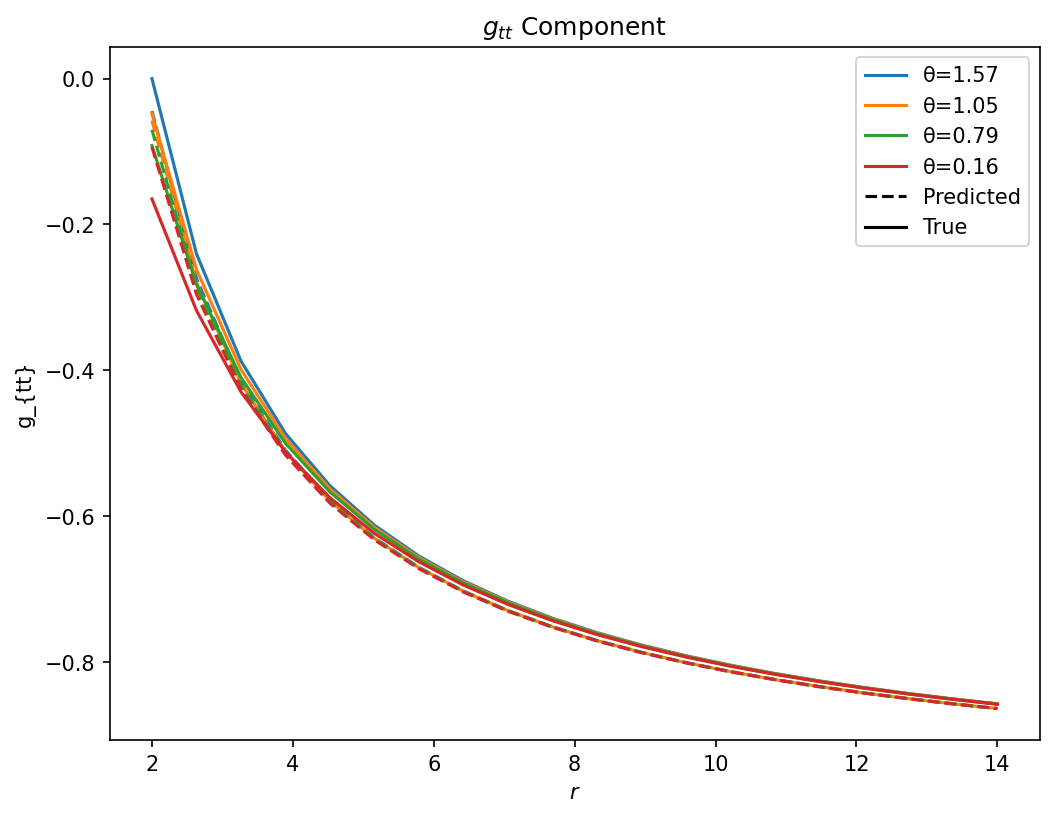

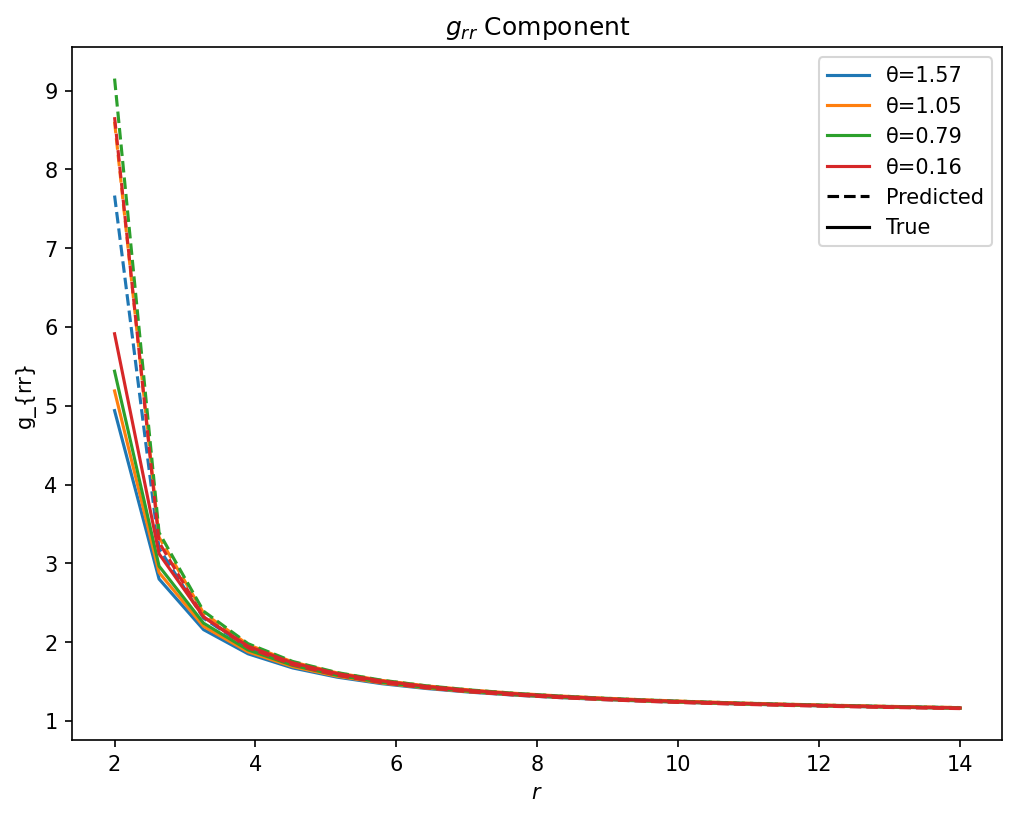

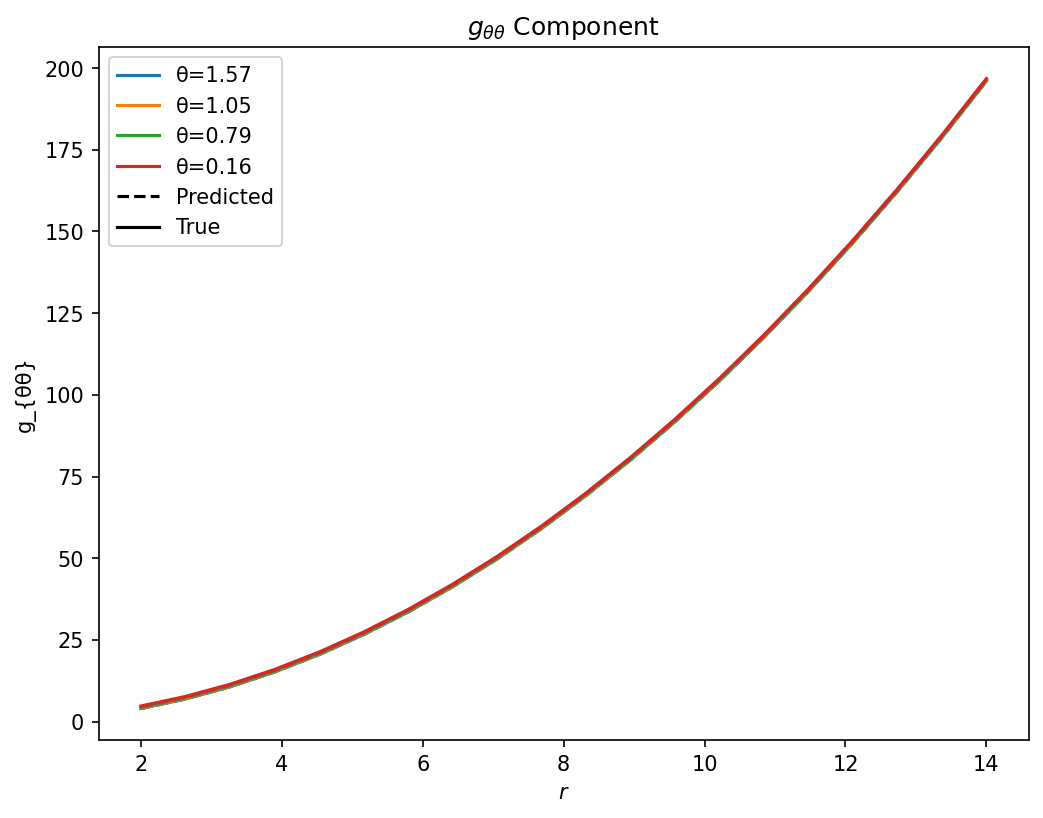

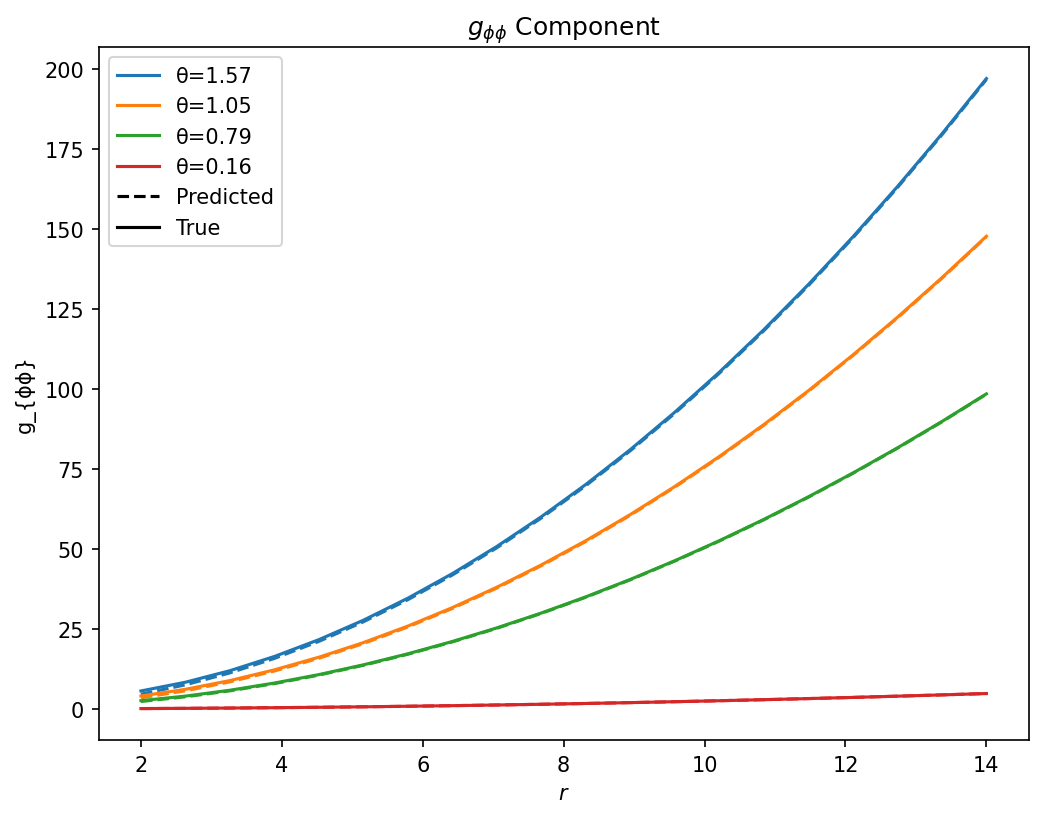

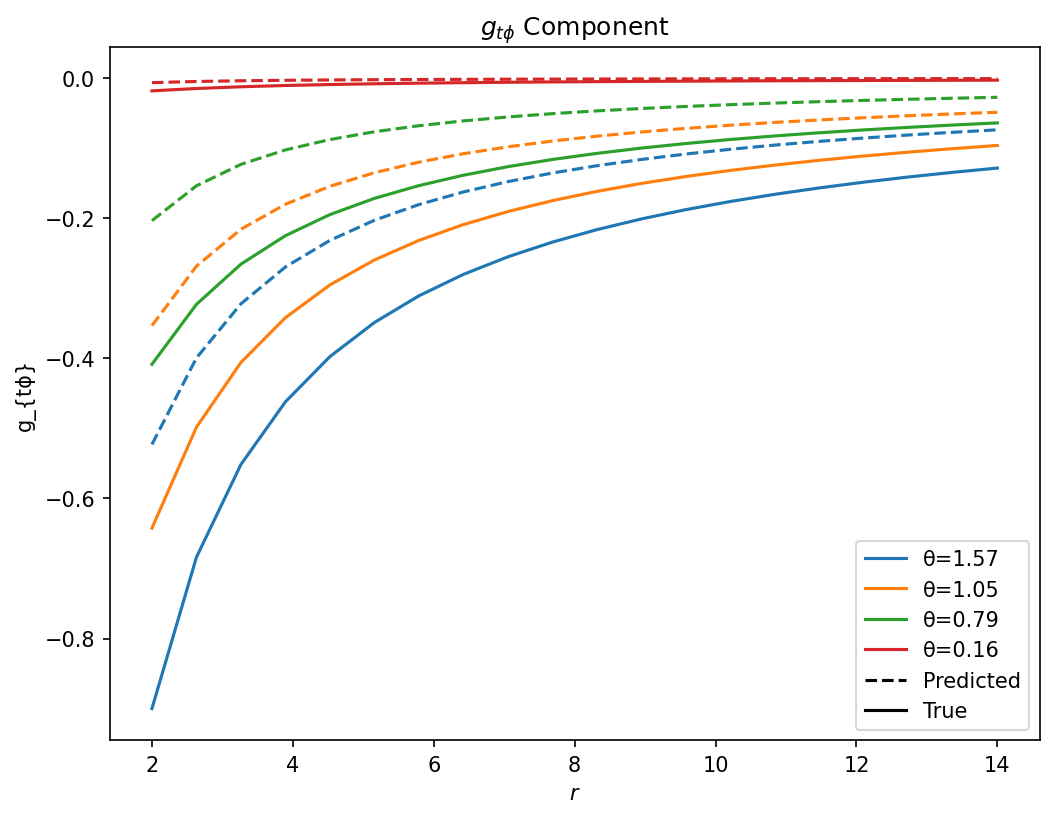

In [70]:
fig, a, b = compare_metrics(net)

/tmp/ipykernel_10611/1297034714.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  θ = torch.tensor(θ, dtype = torch.float32)
/tmp/ipykernel_10611/1297034714.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  θ = torch.tensor(θ, dtype = torch.float32)


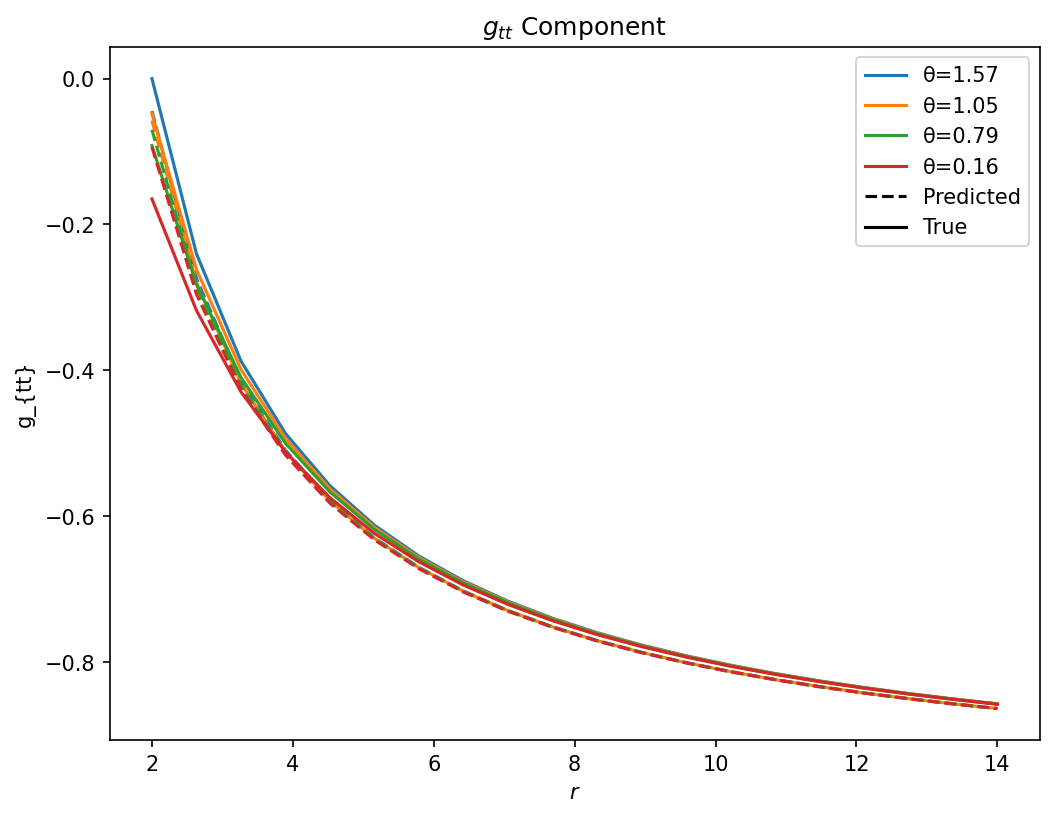

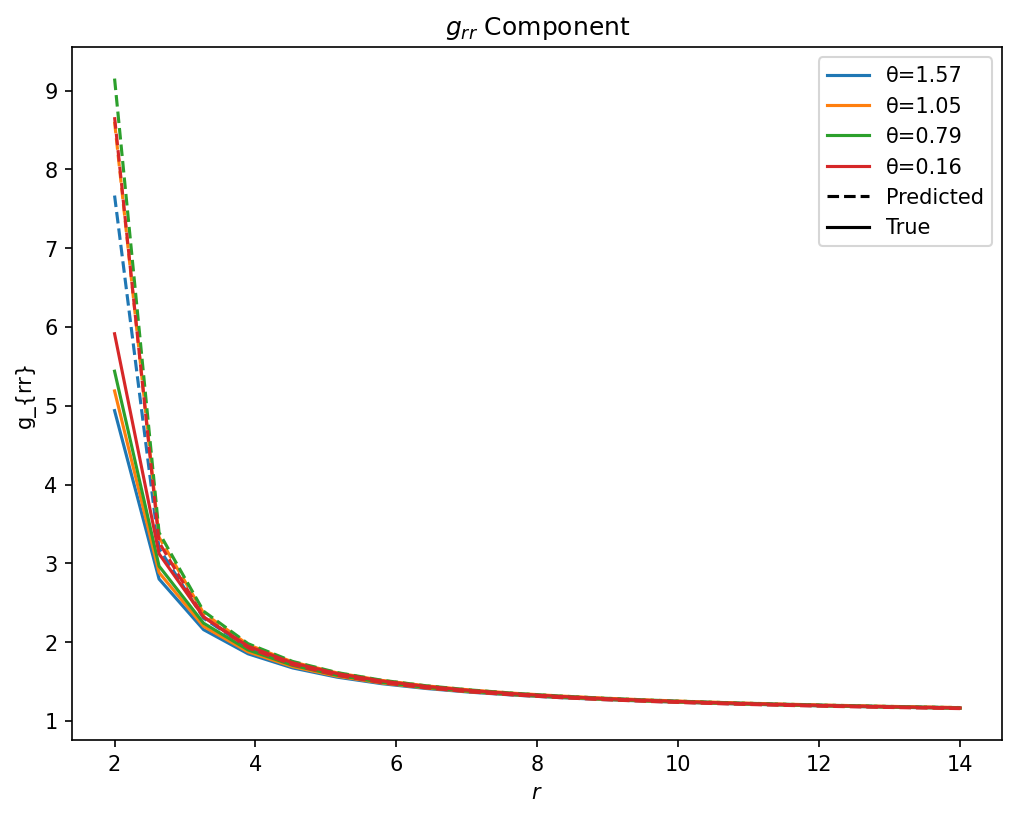

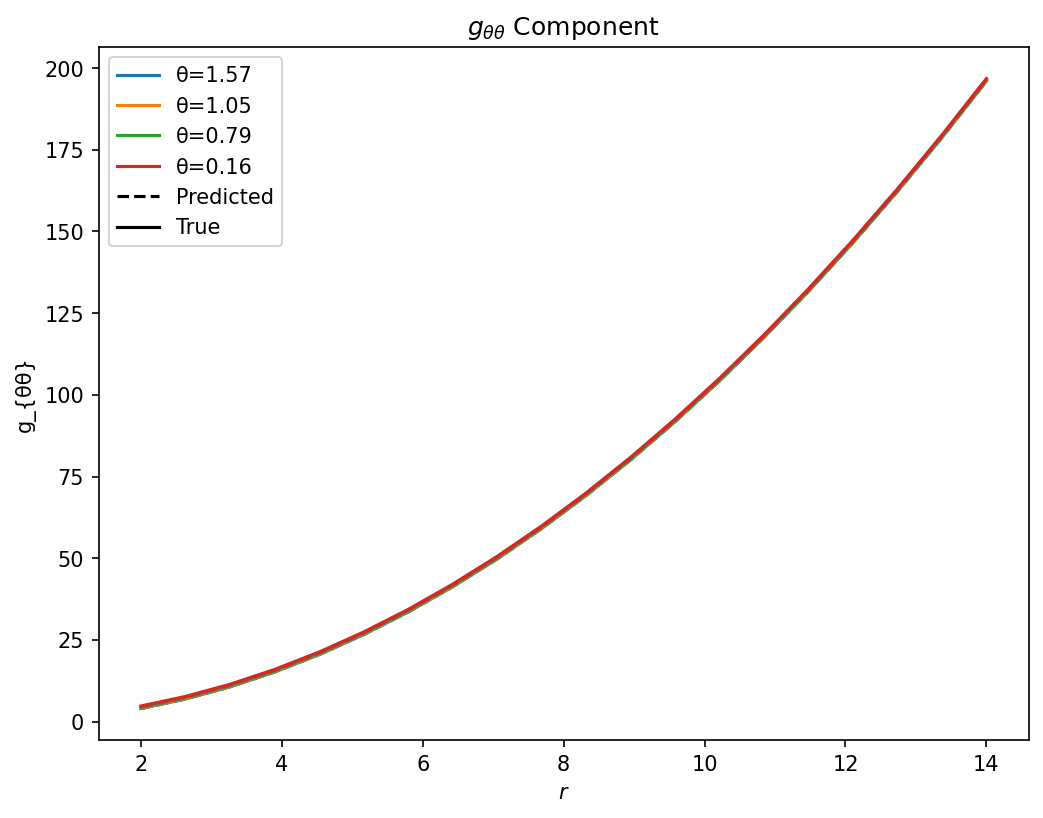

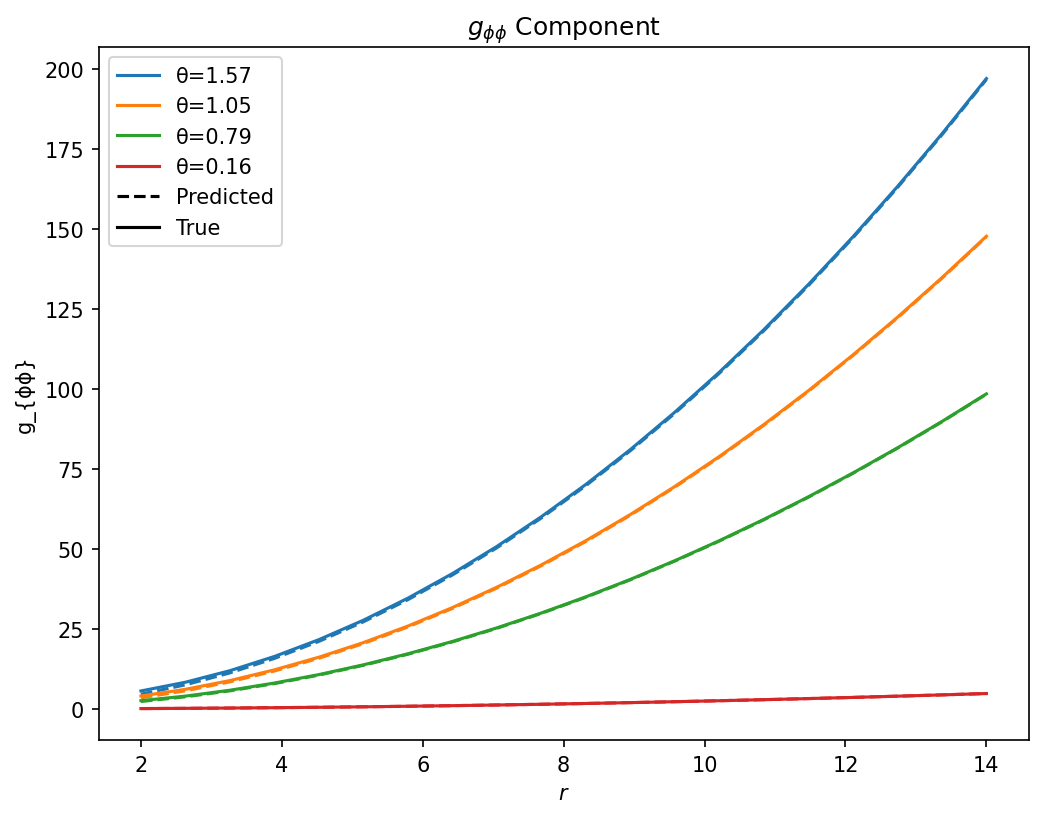

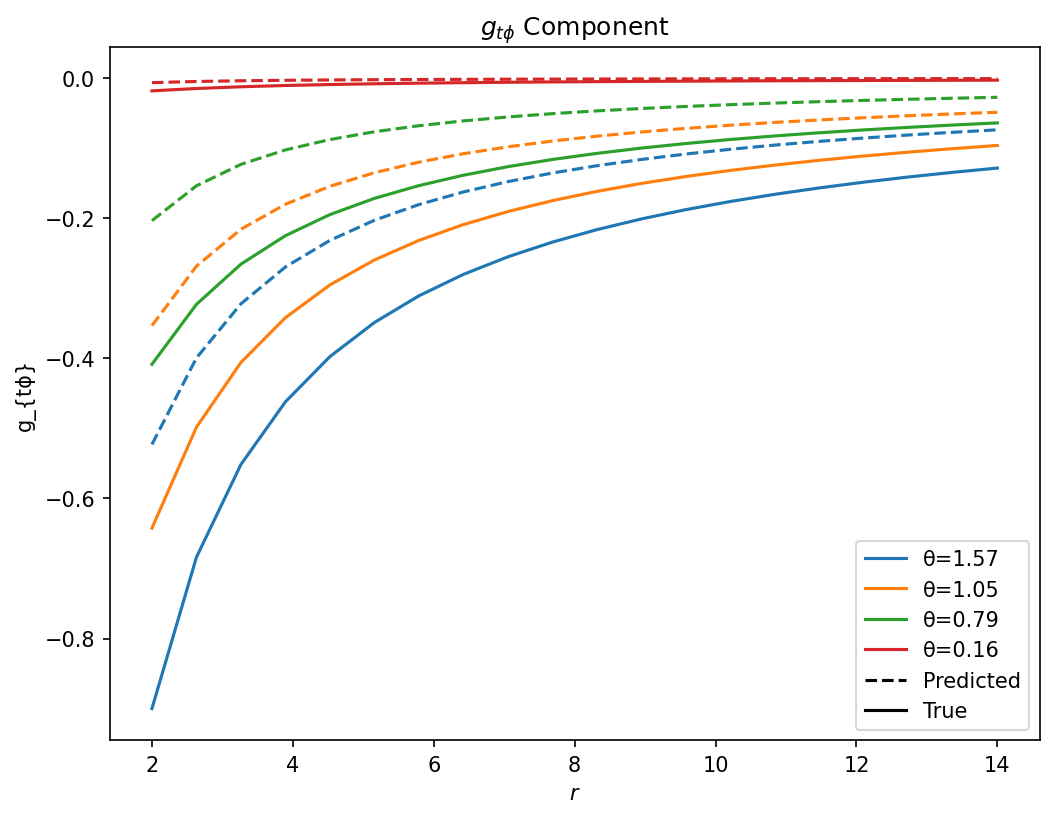

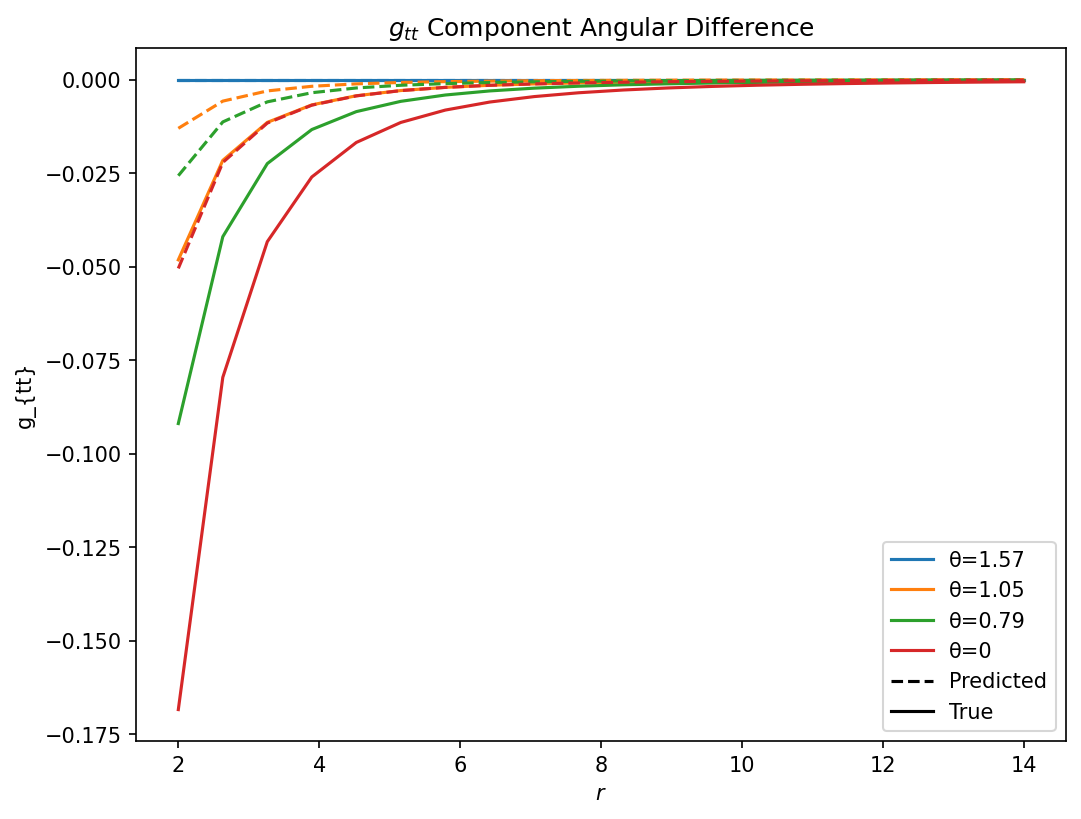

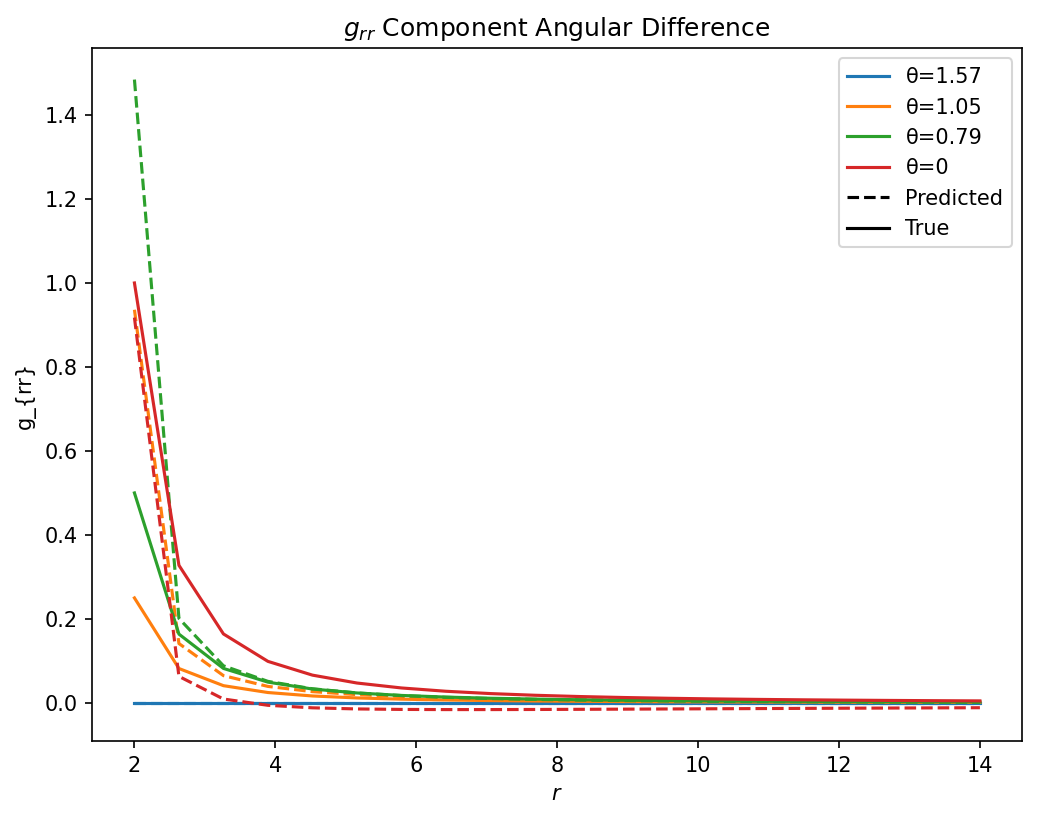

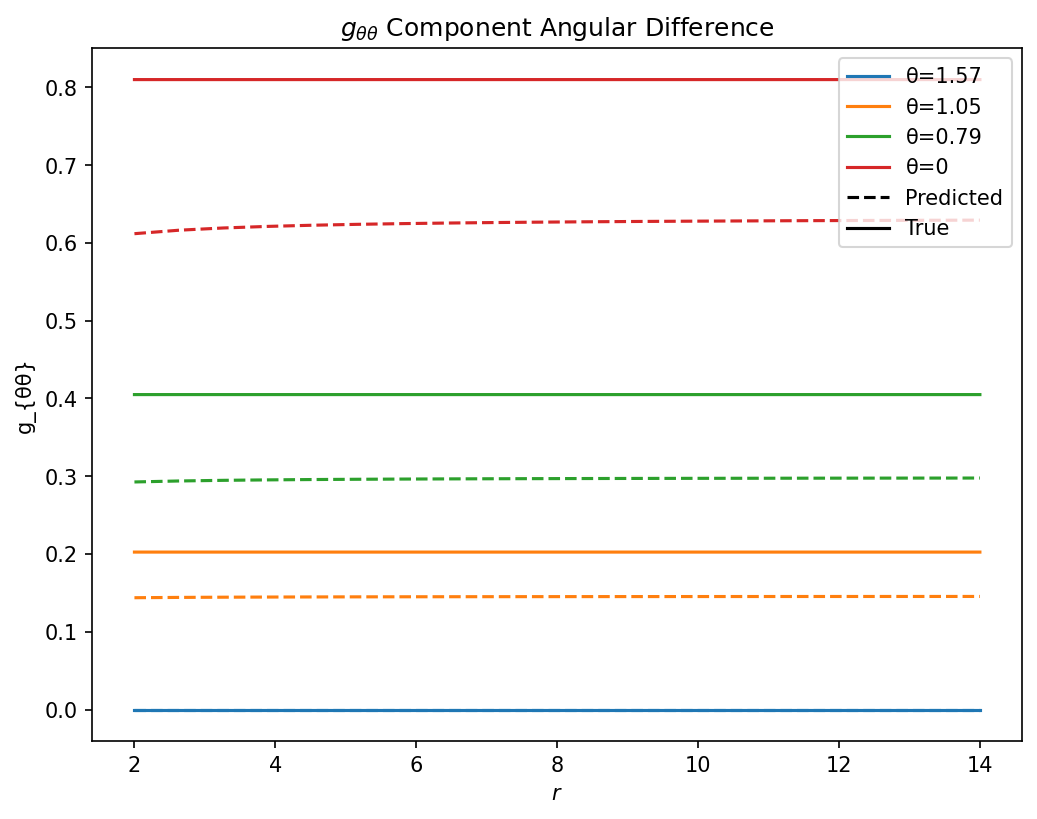

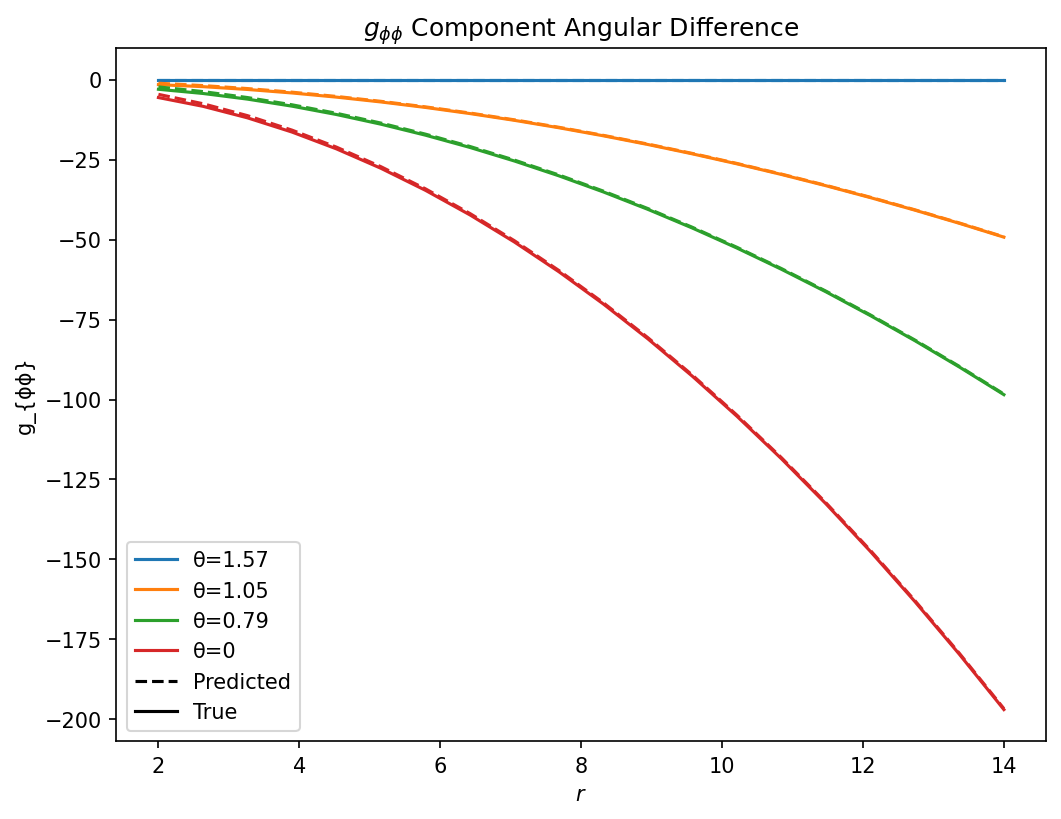

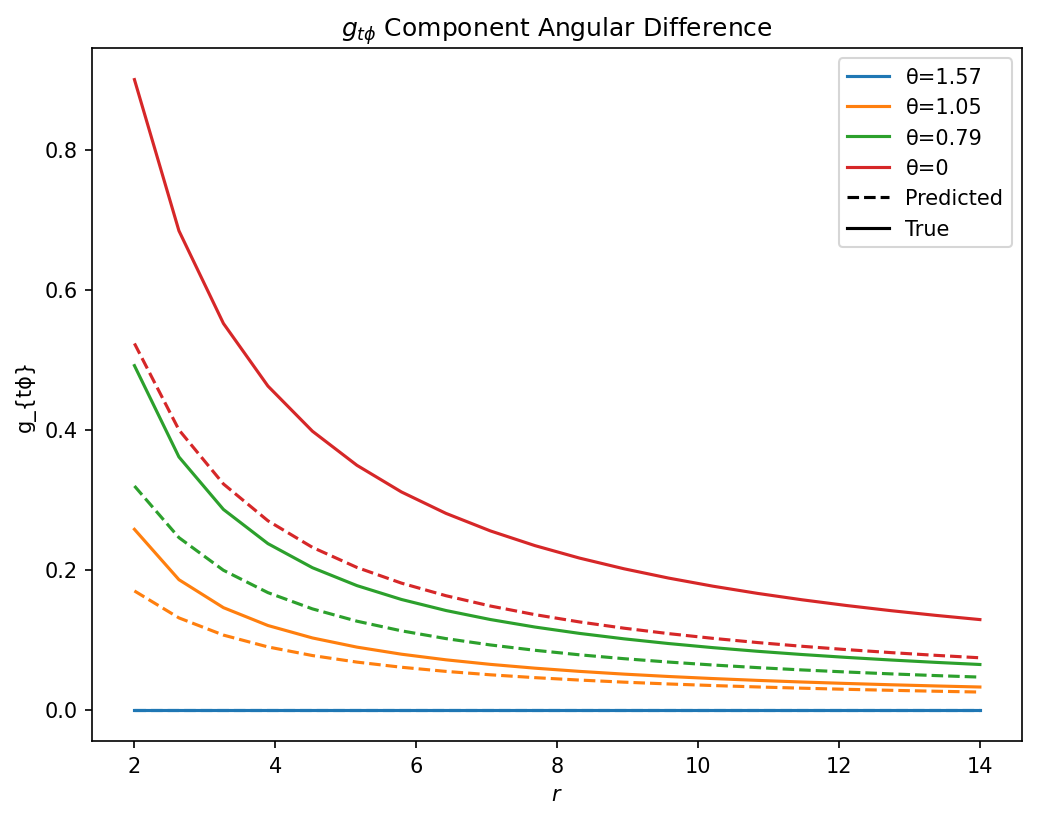

In [71]:
def percent_diff(pred, true):
  return 100 * abs(pred - true) / abs(true)

a, pred_final, true_final = compare_metrics(net)
b, c, d = angular_comparison_metrics(net)